In [1]:
import pandas as pd

# The file appears to be space/whitespace separated
# Using delimiter=r'\s+' to handle multiple spaces/tabs
info = pd.read_csv('info.txt', delimiter=r'\s+')

# Filter columns: keep 'runid' and columns starting with 'ocn.' but exclude 'ocean_fw'
ocn_columns = [col for col in info.columns if col.startswith('ocn.')]
columns_to_keep = ['runid'] + ocn_columns

# Remove 'ocean_fw' if it exists in the selected columns
if 'ocn.l_noise_fw' in columns_to_keep:
    columns_to_keep.remove('ocn.l_noise_fw')

# Select only the desired columns
params = info[columns_to_keep]

# Display the results
print("Original shape:", info.shape)
print("Filtered shape:", params.shape)
print("\nKept columns:")
print(params.columns.tolist())
print("\nFirst 5 rows of filtered data:")
print(params.head())

Original shape: (500, 8)
Filtered shape: (500, 7)

Kept columns:
['runid', 'ocn.diff_dia_min', 'ocn.drag_topo_fac', 'ocn.slope_max', 'ocn.diff_iso', 'ocn.diff_gm', 'ocn.diff_dia_max']

First 5 rows of filtered data:
   runid  ocn.diff_dia_min  ocn.drag_topo_fac  ocn.slope_max  ocn.diff_iso  \
0      1          0.000007           3.140315       0.001005   1311.247475   
1      2          0.000014           3.387432       0.001050   1653.858523   
2      3          0.000012           2.877069       0.000695   1704.188023   
3      4          0.000012           2.615323       0.001058   1453.578268   
4      5          0.000007           3.177072       0.000827   1553.112746   

   ocn.diff_gm  ocn.diff_dia_max  
0  1269.062288          0.000137  
1  1819.713492          0.000160  
2  1445.417076          0.000125  
3  1573.687262          0.000138  
4  1256.308971          0.000118  


In [2]:
# Basic descriptive statistics
print("\nDescriptive Statistics:")
print(params.describe())


Descriptive Statistics:
            runid  ocn.diff_dia_min  ocn.drag_topo_fac  ocn.slope_max  \
count  500.000000        500.000000         500.000000     500.000000   
mean   250.500000          0.000010           2.999944       0.001000   
std    144.481833          0.000002           0.231396       0.000231   
min      1.000000          0.000006           2.601582       0.000600   
25%    125.750000          0.000008           2.799612       0.000800   
50%    250.500000          0.000010           2.999033       0.001000   
75%    375.250000          0.000012           3.200231       0.001200   
max    500.000000          0.000014           3.398624       0.001400   

       ocn.diff_iso  ocn.diff_gm  ocn.diff_dia_max  
count    500.000000   500.000000        500.000000  
mean    1499.297979  1500.325846          0.000150  
std      230.841389   231.311277          0.000023  
min     1100.080860  1100.792227          0.000110  
25%     1299.866116  1300.397590          0.000130  

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import os

# Find all ocn_ts.nc files
model_files = []
run_labels = []
missing_ids=[]
for run_id in range(1, 501):
    file_path = f"{run_id}/ocn_ts.nc"
    if os.path.exists(file_path):
        model_files.append(file_path)
        run_labels.append(str(run_id))
    else:
        missing_ids.append(run_id)
        model_files.append(None) 
drop_ids = [idx-1 for idx in missing_ids]
print(drop_ids)
# Remove rows with indices in missing_ids
# params = params.drop(index=drop_ids)


# Descriptive statistics
print("\nDescriptive Statistics:")
print(params.describe())



[185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201]

Descriptive Statistics:
            runid  ocn.diff_dia_min  ocn.drag_topo_fac  ocn.slope_max  \
count  500.000000        500.000000         500.000000     500.000000   
mean   250.500000          0.000010           2.999944       0.001000   
std    144.481833          0.000002           0.231396       0.000231   
min      1.000000          0.000006           2.601582       0.000600   
25%    125.750000          0.000008           2.799612       0.000800   
50%    250.500000          0.000010           2.999033       0.001000   
75%    375.250000          0.000012           3.200231       0.001200   
max    500.000000          0.000014           3.398624       0.001400   

       ocn.diff_iso  ocn.diff_gm  ocn.diff_dia_max  
count    500.000000   500.000000        500.000000  
mean    1499.297979  1500.325846          0.000150  
std      230.841389   231.311277          0.000023  
min     1100.080860

In [4]:
import numpy as np
from scipy.stats import gaussian_kde
from scipy.signal import welch
from sklearn.cluster import KMeans

def detect_stadials_adaptive(amoc_smooth, method='bimodal_gap', offset=2.5):
    if method == 'percentile':
        return np.percentile(amoc_smooth, 25)

    elif method == 'bimodal_gap':
        hist, edges = np.histogram(amoc_smooth, bins=50, density=True)
        bin_centers = (edges[:-1] + edges[1:]) / 2
        mid_range = (len(hist) // 4, 3 * len(hist) // 4)
        local_min_idx = mid_range[0] + np.argmin(hist[mid_range[0]:mid_range[1]])
        return bin_centers[local_min_idx]

    elif method == 'clustering':
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        kmeans.fit(amoc_smooth.reshape(-1, 1))
        centers = kmeans.cluster_centers_.flatten()
        low, high = np.min(centers), np.max(centers)
        threshold = low + offset
        if threshold > high:
            threshold = np.mean(centers)
        return threshold

    else:
        raise ValueError(f"Unknown method: {method}")


def compute_summary_stats(amoc_data, time_data=None, remove_spinup=True, spinup_fraction=0.02,
                          smooth_win=0, adaptive_threshold=True, threshold_method='clustering',
                          threshold=None, grid_points=100, quantiles=[0.1, 0.5, 0.9],
                          ignore_first_stadial=True, verbose=False):
    
    amoc_data = np.asarray(amoc_data)
    if time_data is None:
        time_data = np.arange(len(amoc_data))
    else:
        time_data = np.asarray(time_data)

    # Remove spinup
    if remove_spinup:
        start_idx = int(len(amoc_data) * spinup_fraction)
        amoc_data = amoc_data[start_idx:]
        time_data = time_data[start_idx:]
        time_data = time_data - time_data[0]

    # Basic stats
    basic_stats = {
        'mean': np.mean(amoc_data),
        'std': np.std(amoc_data),
        'quantiles': np.quantile(amoc_data, quantiles)
    }

    # Smooth
    if smooth_win > 1:
        kernel = np.ones(smooth_win) / smooth_win
        amoc_smooth = np.convolve(amoc_data, kernel, mode='same')
    else:
        amoc_smooth = amoc_data.copy()

    # PDF using KDE
    kde = gaussian_kde(amoc_data)
    x_grid = np.linspace(amoc_data.min(), amoc_data.max(), grid_points)
    pdf_vals = kde(x_grid)
    pdf_vals /= np.trapezoid(pdf_vals, x_grid)  # normalize

    # Threshold
    if adaptive_threshold:
        threshold_val = detect_stadials_adaptive(amoc_smooth, method=threshold_method)
    else:
        threshold_val = np.percentile(amoc_smooth, 25) if threshold is None else threshold

    # Detect stadials
    is_stadial = amoc_smooth < threshold_val
    transitions = np.diff(is_stadial.astype(int))
    stadial_starts = np.where(transitions == 1)[0] + 1
    stadial_ends = np.where(transitions == -1)[0] + 1

    if is_stadial[0] and not ignore_first_stadial:
        stadial_starts = np.insert(stadial_starts, 0, 0)
    if is_stadial[-1]:
        stadial_ends = np.append(stadial_ends, len(amoc_smooth))

    # Robust alignment
    if ignore_first_stadial and len(stadial_ends) > len(stadial_starts):
        if len(stadial_starts) == 0 or stadial_ends[0] < stadial_starts[0]:
            stadial_ends = stadial_ends[1:]
    if len(stadial_starts) > len(stadial_ends):
        stadial_starts = stadial_starts[:len(stadial_ends)]
    if len(stadial_starts) != len(stadial_ends):
        min_len = min(len(stadial_starts), len(stadial_ends))
        stadial_starts = stadial_starts[:min_len]
        stadial_ends = stadial_ends[:min_len]

    n_stadials = len(stadial_starts)

    # Stadial durations & waiting times
    if n_stadials > 0:
        stadial_durations = time_data[stadial_ends - 1] - time_data[stadial_starts]
        avg_stadial_duration = np.mean(stadial_durations)
        waiting_times = np.diff(time_data[stadial_starts]) if n_stadials > 1 else np.array([])
        avg_waiting_time = np.mean(waiting_times) if len(waiting_times) > 0 else 0.0
    else:
        stadial_durations = np.array([])
        avg_stadial_duration = 0.0
        waiting_times = np.array([])
        avg_waiting_time = 0.0

    # Amplitude
    interstadial_max = []
    stadial_min = []
    for i in range(n_stadials - 1):
        interseg = amoc_smooth[stadial_ends[i]:stadial_starts[i + 1]]
        stadseg = amoc_smooth[stadial_starts[i]:stadial_ends[i]]
        if len(interseg) > 0:
            interstadial_max.append(np.max(interseg))
        if len(stadseg) > 0:
            stadial_min.append(np.min(stadseg))
    amplitude_vals = np.array(interstadial_max) - np.array(stadial_min[:len(interstadial_max)])
    avg_amplitude = np.mean(amplitude_vals) if len(amplitude_vals) > 0 else 0.0

    # PSD (optional)
    f, Pxx = welch(amoc_data, fs=1.0, nperseg=min(256, len(amoc_data)))
    psd_bins = np.log(Pxx[:10]) if len(Pxx) >= 10 else np.log(Pxx)

    # Combine all results
    stats = {
        'mean': basic_stats['mean'],
        'std': basic_stats['std'],
        'quantiles': basic_stats['quantiles'],
        'pdf': pdf_vals,
        'x_grid': x_grid,
        'threshold': threshold_val,
        'n_stadials': n_stadials,
        'stadial_starts': stadial_starts,
        'stadial_ends': stadial_ends,
        'avg_stadial_duration': avg_stadial_duration,
        'stadial_durations': stadial_durations,
        'avg_waiting_time': avg_waiting_time,
        'waiting_times': waiting_times,
        'avg_amplitude': avg_amplitude,
        'psd_bins': psd_bins
    }

    if verbose:
        print(stats)

    return stats


In [5]:
from scipy import signal

def lowpass_filter(data, cutoff_years, dt=1.0):
    """
    Apply a lowpass Butterworth filter to time series data.
    
    Parameters:
    -----------
    data : array
        Input time series
    cutoff_years : float
        Cutoff period in years (e.g., 100 means preserve variations longer than 100 years)
    dt : float
        Time step in years (default 1.0 for yearly data)
    
    Returns:
    --------
    filtered_data : array
        Lowpass filtered time series
    """
    # Convert cutoff period to frequency
    cutoff_freq = 1.0 / cutoff_years  # cycles per year
    nyquist_freq = 1.0 / (2.0 * dt)   # Nyquist frequency
    normalized_cutoff = cutoff_freq / nyquist_freq
    
    # Design Butterworth filter (order=4 is a good default)
    b, a = signal.butter(4, normalized_cutoff, btype='low', analog=False)
    
    # Apply filter (filtfilt does forward-backward filtering to avoid phase shift)
    filtered_data = signal.filtfilt(b, a, data)
    
    return filtered_data

from sklearn.decomposition import PCA

# Flag to control whether to apply the lowpass filter
apply_filter = True  # Set to False to skip filtering

# Default run
default_file = "../default_long_run/ocn_ts.nc"
ds_default = xr.open_dataset(default_file)
amoc_default = ds_default.amoc26N.values
time_default = ds_default.time.values
ds_default.close()

# Apply lowpass filter if desired
if apply_filter:
    amoc_default_processed = lowpass_filter(amoc_default, cutoff_years=100)
else:
    amoc_default_processed = amoc_default

# Compute default summary statistics
default_stats = compute_summary_stats(amoc_default_processed, time_default)

print(len(model_files))

# Ensemble runs
ensemble_stats = []
for file in model_files:
    if file:
        ds = xr.open_dataset(file)
        amoc = ds.amoc26N.values
        time = ds.time.values
        ds.close()
        
        # Apply same optional lowpass filter
        if apply_filter:
            amoc_processed = lowpass_filter(amoc, cutoff_years=100)
        else:
            amoc_processed = amoc
        
        stats = compute_summary_stats(amoc_processed, time)
        ensemble_stats.append(stats)
    else: 
        ensemble_stats.append(None)

# FIT PCA on ensemble PDFs
all_pdfs = [stats['pdf'] for stats in ensemble_stats if stats is not None]
print(f"Fitting PCA on {len(all_pdfs)} ensemble PDFs...")
pdf_pca_components = 5  # Set your desired number of components
pca_model = PCA(n_components=pdf_pca_components)
pca_model.fit(np.array(all_pdfs))
print(f"PCA explained variance ratio: {pca_model.explained_variance_ratio_}")
print(f"Total variance explained: {pca_model.explained_variance_ratio_.sum():.3f}")

# ADD PCA components to existing stats
default_stats['pca_components'] = pca_model.transform(default_stats['pdf'].reshape(1, -1)).flatten()

for stats in ensemble_stats:
    if stats is not None:
        stats['pca_components'] = pca_model.transform(stats['pdf'].reshape(1, -1)).flatten()

print("Done! All stats now contain 'pca_components'")

500
Fitting PCA on 483 ensemble PDFs...
PCA explained variance ratio: [0.43511648 0.16012526 0.12019246 0.09022088 0.06871605]
Total variance explained: 0.874
Done! All stats now contain 'pca_components'


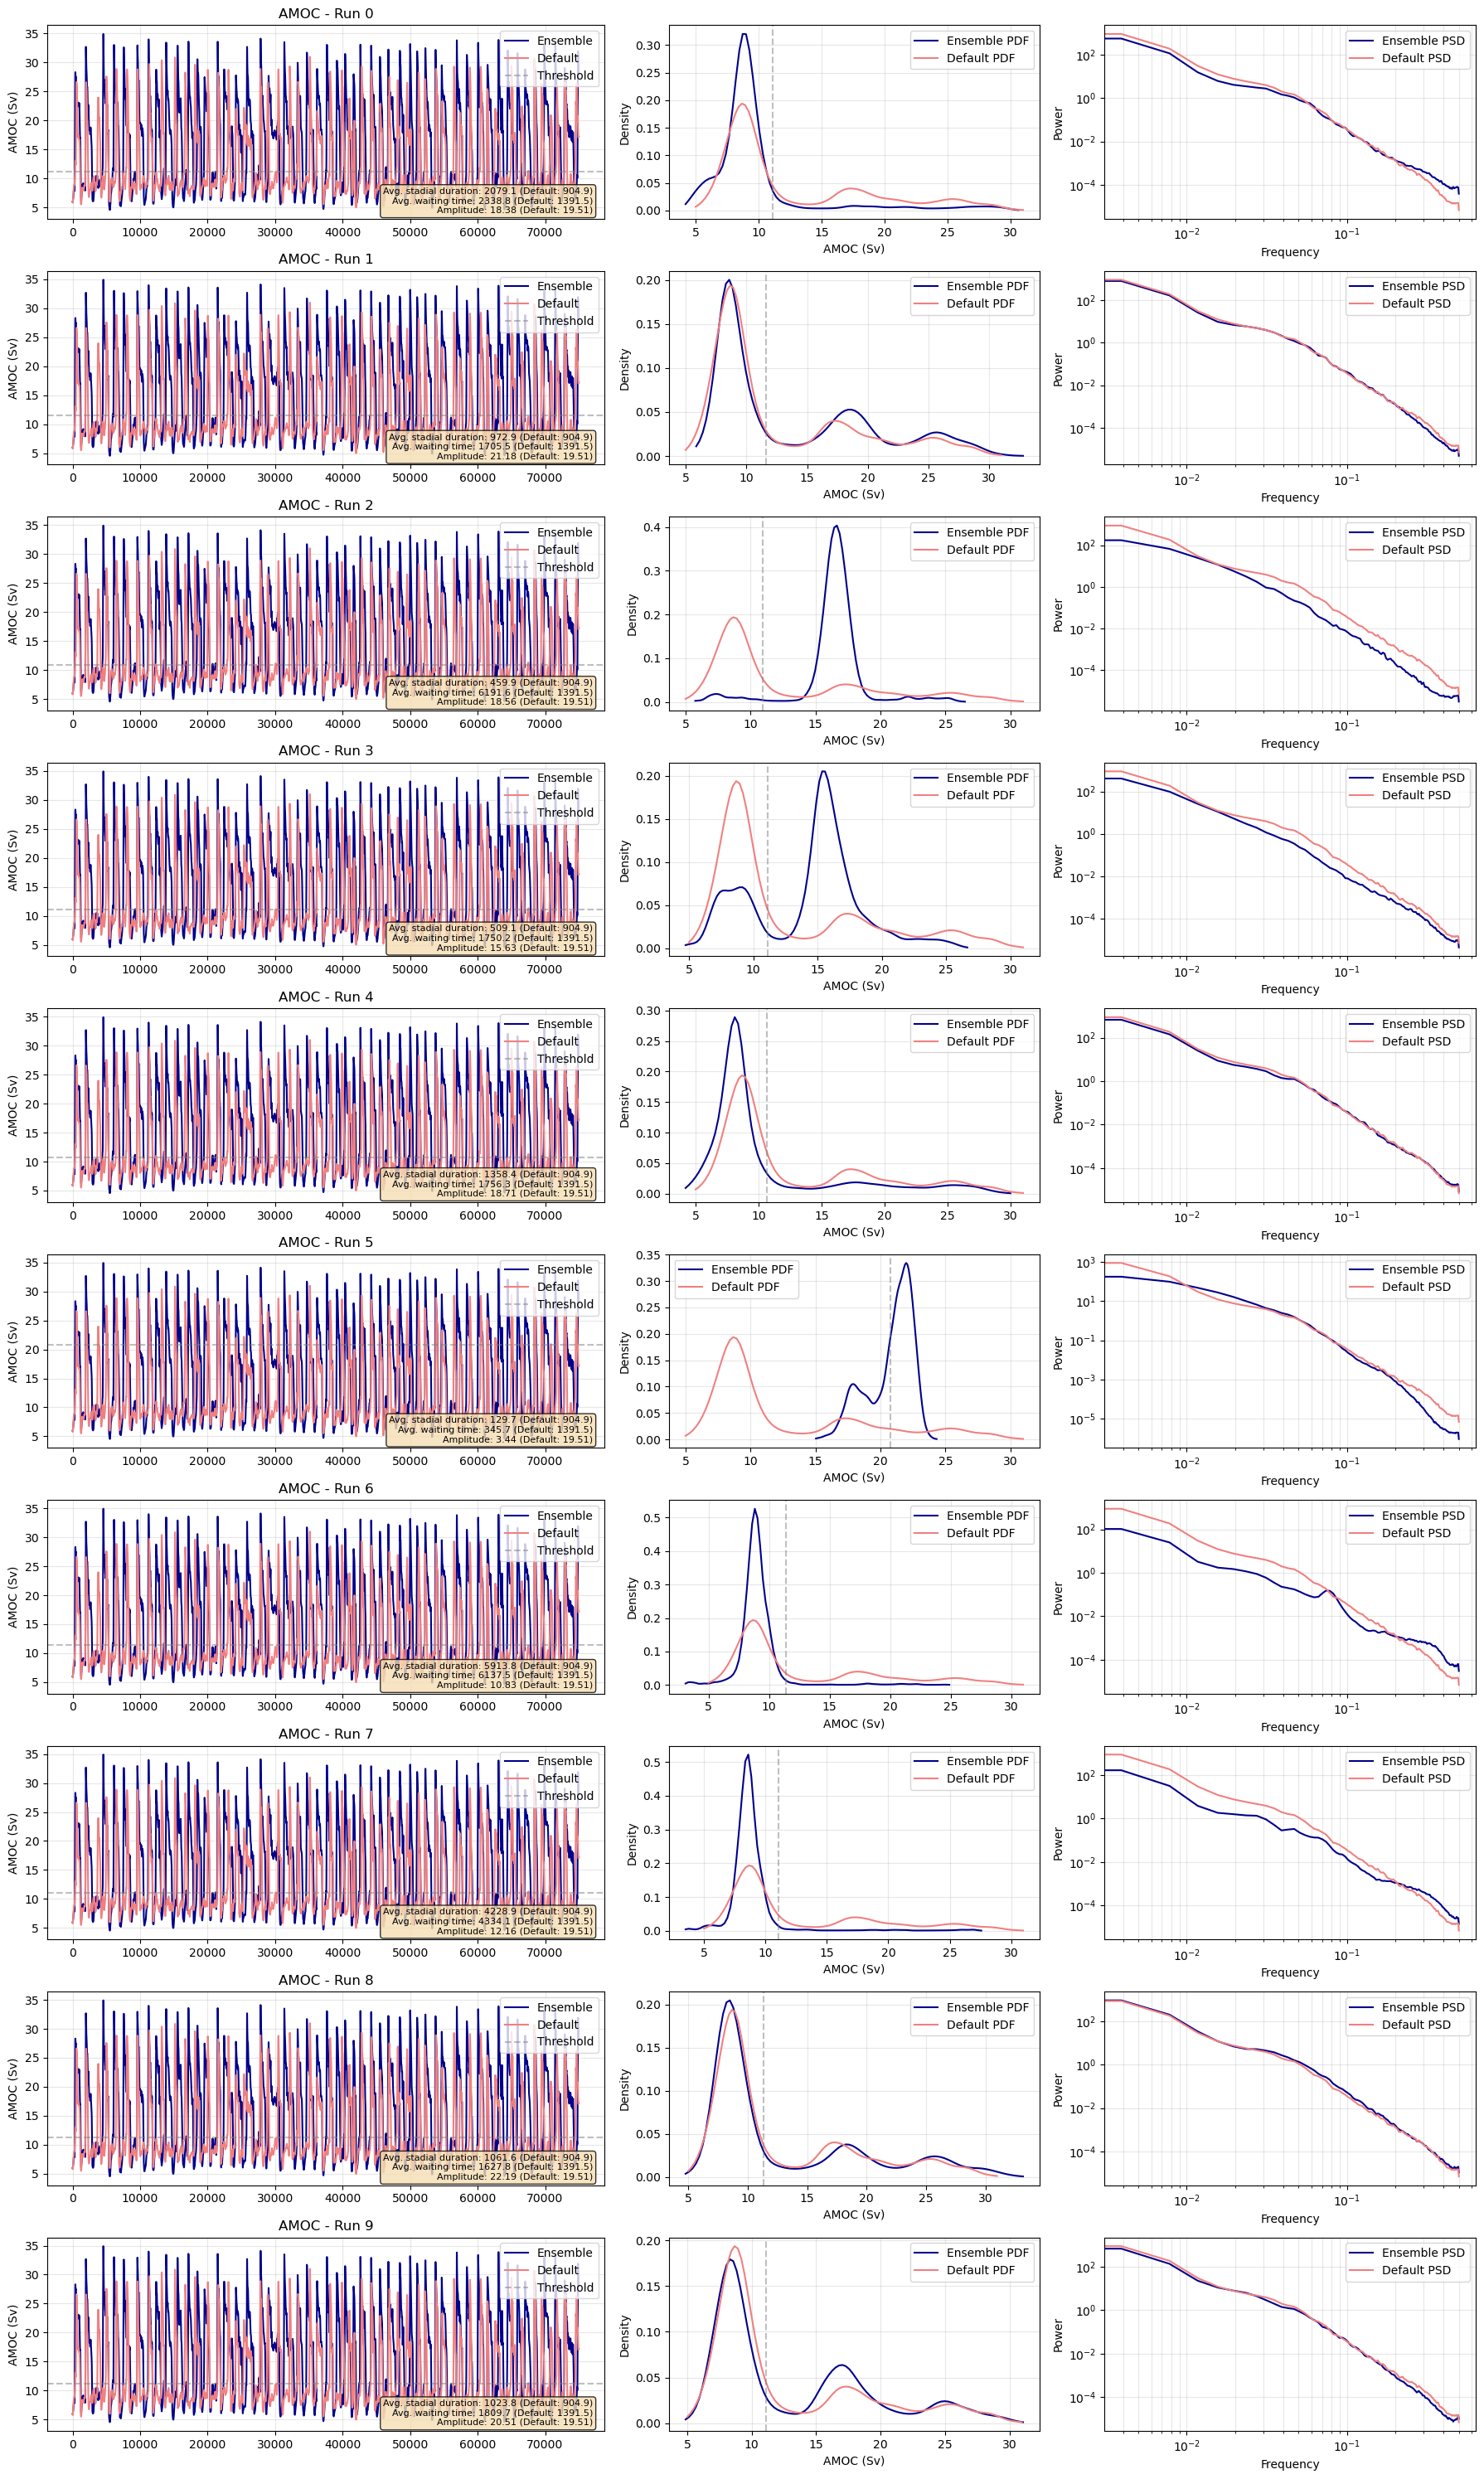

In [6]:
import matplotlib.pyplot as plt
import xarray as xr
from scipy.signal import welch
import numpy as np

n_runs = 10
fig, axes = plt.subplots(n_runs, 3, figsize=(18, 3*n_runs), gridspec_kw={'width_ratios': [3, 2, 2]})

# Handle single run
if n_runs == 1:
    axes = [axes]

for i, (stats, file) in enumerate(zip(ensemble_stats[:n_runs], model_files[:n_runs])):
    ds = xr.open_dataset(file)
    amoc = ds.amoc26N.values
    ds.close()
    
    # ----------------------------
    # 1. Time series plot
    # ----------------------------
    axes[i][0].plot(amoc_processed, color='darkblue', label='Ensemble')
    axes[i][0].plot(amoc_default_processed, color='lightcoral', label='Default')
    axes[i][0].axhline(stats['threshold'], color='gray', linestyle='--', alpha=0.5, label='Threshold')
    axes[i][0].set_ylabel('AMOC (Sv)')
    axes[i][0].set_title(f'AMOC - Run {i}')
    axes[i][0].legend()
    axes[i][0].grid(alpha=0.3)
    
    # Add summary stats text
    axes[i][0].text(
        0.98, 0.02,
        f"Avg. stadial duration: {stats['avg_stadial_duration']:.1f} (Default: {default_stats['avg_stadial_duration']:.1f})\n"
        f"Avg. waiting time: {stats['avg_waiting_time']:.1f} (Default: {default_stats['avg_waiting_time']:.1f})\n"
        f"Amplitude: {stats['avg_amplitude']:.2f} (Default: {default_stats['avg_amplitude']:.2f})",
        transform=axes[i][0].transAxes,
        fontsize=8, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    
    # ----------------------------
    # 2. PDF plot
    # ----------------------------
    axes[i][1].plot(stats['x_grid'], stats['pdf'], color='darkblue', label='Ensemble PDF')
    axes[i][1].plot(default_stats['x_grid'], default_stats['pdf'], color='lightcoral', label='Default PDF')
    axes[i][1].axvline(stats['threshold'], color='gray', linestyle='--', alpha=0.5)
    axes[i][1].set_ylabel('Density')
    axes[i][1].set_xlabel('AMOC (Sv)')
    axes[i][1].legend()
    axes[i][1].grid(alpha=0.3)
    
    # ----------------------------
    # 3. PSD plot
    # ----------------------------
    fs = 1.0  # sampling frequency (adjust if needed)
    f, Pxx = welch(amoc, fs=fs, nperseg=min(256, len(amoc)))
    f_default, Pxx_default = welch(amoc_default, fs=fs, nperseg=min(256, len(amoc_default)))
    
    axes[i][2].plot(f, Pxx, color='darkblue', label='Ensemble PSD')
    axes[i][2].plot(f_default, Pxx_default, color='lightcoral', label='Default PSD')
    axes[i][2].set_xscale('log')
    axes[i][2].set_yscale('log')
    axes[i][2].set_xlabel('Frequency')
    axes[i][2].set_ylabel('Power')
    axes[i][2].legend()
    axes[i][2].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()


In [7]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern
from sklearn.decomposition import PCA

class GPEmulatorPDF:
    def __init__(self, kernel=None, scaler_X=None, scaler_y=None):
        """
        GP emulator that predicts PCA components directly.
        
        Parameters
        ----------
        kernel : GP kernel
            Kernel for the GP. If None, uses RBF + WhiteKernel
        scaler_X : scaler for input features
            If None, uses StandardScaler
        scaler_y : scaler for output features  
            If None, uses StandardScaler
        """
        self.kernel = kernel if kernel is not None else RBF(1.0) + WhiteKernel(1e-6)
        self.scaler_X = scaler_X if scaler_X is not None else StandardScaler()
        self.scaler_y = scaler_y if scaler_y is not None else StandardScaler()
        self.pca = None  # Will be set externally
        self.gp_model = None
        self.is_fitted = False
        self.pdf_xpoints = None  # Will be set from default_stats if needed
        self.n_pca_components = None  # Track this explicitly
        
    def fit(self, X, Y, pca_components):
        """
        Fit the GP emulator.
        
        Parameters
        ----------
        X : array-like, shape (n_samples, n_input_parameters)
            Input parameters (e.g., climate model parameters)
        Y : array-like, shape (n_samples, n_other_summary_stats)
            Other summary statistics (avg_stadial_duration, avg_waiting_time, amplitude, psd_bins, quantiles)
        pca_components : array-like, shape (n_samples, n_pca_components)
            Pre-computed PCA components for each sample
        """
        # Store number of PCA components
        self.n_pca_components = pca_components.shape[1]
        
        # Combine PCA components and other summary stats
        Y_full = np.hstack([pca_components, Y])
        
        # Scale
        X_scaled = self.scaler_X.fit_transform(X)
        Y_scaled = self.scaler_y.fit_transform(Y_full)
        
        # Fit single multi-output GP (captures correlations between outputs)
        self.gp_model = GaussianProcessRegressor(
            kernel=self.kernel, 
            normalize_y=True,
            n_restarts_optimizer=3
        )
        self.gp_model.fit(X_scaled, Y_scaled)
        self.is_fitted = True
        
    def predict(self, X_new, return_std=True):
        """
        Predict PCA components and other summary stats for new inputs.
        
        Returns
        -------
        pca_components_pred : array, shape (n_samples, n_pca_components)
            Predicted PCA components
        Y_pred : array, shape (n_samples, n_other_summary_stats)
            Predicted other summary statistics
        pca_components_std : array, optional, shape (n_samples, n_pca_components)
            Uncertainty in PCA components
        Y_std : array, optional, shape (n_samples, n_other_summary_stats)
            Uncertainty in other summary statistics
        """
        if not self.is_fitted:
            raise RuntimeError("GPEmulatorPDF must be fitted first.")
        
        X_scaled = self.scaler_X.transform(X_new)
        
        # Predict with single GP
        if return_std:
            mean_scaled, std_scaled = self.gp_model.predict(X_scaled, return_std=True)
        else:
            mean_scaled = self.gp_model.predict(X_scaled)
            std_scaled = None
        
        # Inverse scaling
        mean_full = self.scaler_y.inverse_transform(mean_scaled)
        
        if return_std and std_scaled is not None:
            std_full = std_scaled * self.scaler_y.scale_
        else:
            std_full = None
        
        # Split PCA components and other summary stats
        pca_components_pred = mean_full[:, :self.n_pca_components]
        Y_pred = mean_full[:, self.n_pca_components:]
        
        if return_std and std_full is not None:
            pca_components_std = std_full[:, :self.n_pca_components]
            Y_std = std_full[:, self.n_pca_components:]
            
            return pca_components_pred, Y_pred, pca_components_std, Y_std
        else:
            return pca_components_pred, Y_pred
    
    def reconstruct_pdf(self, pca_components, x_grid=None):
        """
        Reconstruct PDF from PCA components.
        
        Parameters
        ----------
        pca_components : array, shape (n_samples, n_pca_components) or (n_pca_components,)
            PCA components to reconstruct from
        x_grid : array, optional
            Grid points for the PDF. If None, uses self.pdf_xpoints
        
        Returns
        -------
        pdf : array, shape (n_samples, len(x_grid)) or (len(x_grid),)
            Reconstructed PDF values (non-negative and normalized)
        """
        if self.pca is None:
            raise RuntimeError("PCA model not set. Set emulator.pca before calling reconstruct_pdf().")
        
        # Handle single sample
        if pca_components.ndim == 1:
            pca_components = pca_components.reshape(1, -1)
            single_sample = True
        else:
            single_sample = False
        
        # Reconstruct PDF from PCA
        pdf_reconstructed = self.pca.inverse_transform(pca_components)
        
        # Ensure PDF is valid: non-negative and normalized
        pdf_reconstructed = np.maximum(pdf_reconstructed, 0)  # Remove negative values
        
        # Normalize each PDF to integrate to 1
        if x_grid is None:
            if self.pdf_xpoints is None:
                raise ValueError("Either provide x_grid or set self.pdf_xpoints")
            x_grid = self.pdf_xpoints
        
        for i in range(len(pdf_reconstructed)):
            integral = np.trapezoid(pdf_reconstructed[i], x_grid)
            if integral > 0:
                pdf_reconstructed[i] /= integral
        
        if single_sample:
            return pdf_reconstructed[0]
        else:
            return pdf_reconstructed

In [8]:
# Define what counts as "DO-oscillating behavior"
min_stadials_threshold = 27 # Adjust based on your data

# Create regime labels
has_DO_behavior = np.array([s['n_stadials'] >= min_stadials_threshold if s else False for s in ensemble_stats ])
# Your existing arrays
spurious_runs = np.array([
    s['n_stadials'] >= 75 if s else False
    for s in ensemble_stats
])

spurious2 = [7, 10, 27, 40, 127, 205, 206, 222, 239, 244, 255, 257, 292, 368, 414, 421, 441, 445, 447, 474, 475]

has_DO_behavior[spurious2] = False
has_DO_behavior[np.where(spurious_runs == True)] = False

print(np.where(has_DO_behavior == 0))

print(f"Total runs: {len(ensemble_stats)}")
print(f"DO-oscillating runs: {has_DO_behavior.sum()} ({100*has_DO_behavior.sum()/len(ensemble_stats):.1f}%)")
print(f"Stable runs: {(~has_DO_behavior).sum()} ({100*(~has_DO_behavior).sum()/len(ensemble_stats):.1f}%)")

# Check where default falls
print(f"\nDefault run has {default_stats['n_stadials']} stadials → {'DO-oscillating' if default_stats['n_stadials'] >= min_stadials_threshold else 'Stable'}")

(array([  2,   5,   6,   7,  10,  27,  31,  33,  34,  35,  36,  38,  40,
        42,  43,  44,  45,  47,  49,  50,  62,  64,  66,  67,  69,  71,
        74,  75,  81,  86,  87,  88,  91,  93,  99, 100, 102, 106, 111,
       120, 122, 127, 128, 130, 131, 132, 133, 134, 135, 136, 139, 144,
       149, 151, 152, 157, 163, 165, 169, 170, 173, 176, 179, 182, 185,
       186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198,
       199, 200, 201, 204, 205, 206, 209, 210, 211, 218, 220, 222, 228,
       230, 231, 239, 241, 243, 244, 250, 255, 257, 260, 262, 263, 270,
       271, 274, 276, 284, 286, 289, 290, 292, 294, 297, 304, 307, 308,
       309, 313, 314, 316, 320, 322, 329, 331, 339, 342, 343, 354, 357,
       360, 361, 364, 365, 366, 367, 368, 369, 374, 375, 376, 380, 382,
       383, 386, 387, 393, 395, 400, 404, 405, 407, 410, 414, 420, 421,
       422, 424, 426, 428, 430, 436, 441, 445, 447, 449, 451, 454, 455,
       457, 464, 474, 475, 480, 484, 485, 490, 497]),)
Total ru

In [9]:
# ----------------------------
# 1. Prepare data
# ----------------------------
# Filter out None entries in ensemble_stats
valid = [s is not None for s in ensemble_stats]
ensemble_stats_valid = [s for s in ensemble_stats if s is not None]
params_valid = params[valid]
has_DO_behavior_valid = has_DO_behavior[valid]

param_cols = [
    'ocn.diff_dia_min', 'ocn.drag_topo_fac', 'ocn.slope_max',
    'ocn.diff_iso', 'ocn.diff_gm', 'ocn.diff_dia_max'
]
X = params_valid[param_cols].values

other_stats = np.array([
    [s['mean'], s['std'],
     s['avg_stadial_duration'], s['avg_waiting_time'],
     s['avg_amplitude'], s['n_stadials']]
    for s in ensemble_stats_valid
])

# Extract PCA components
pca_components = np.array([s['pca_components'] for s in ensemble_stats_valid])

# Filter for DO behavior
X_DO = X[has_DO_behavior_valid]
other_stats_DO = other_stats[has_DO_behavior_valid]
pca_components_DO = pca_components[has_DO_behavior_valid]
ensemble_stats_DO = [
    s for s, m in zip(ensemble_stats_valid, has_DO_behavior_valid) if m
]

# Set final X and other_stats
X = X_DO
other_stats = other_stats_DO
pca_components = pca_components_DO

print(f"Number of DO runs: {len(X_DO)}")

# ----------------------------
# 2. Assemble PDFs
# ----------------------------
pdf_matrix = np.array([s['pdf'] for s in ensemble_stats_valid])  # shape (n_runs, n_grid)
pdf_matrix = pdf_matrix[has_DO_behavior_valid]

print(f"PDF matrix shape: {pdf_matrix.shape}")
print(f"PCA components shape: {pca_components.shape}")

Number of DO runs: 322
PDF matrix shape: (322, 100)
PCA components shape: (322, 5)


In [10]:
# ----------------------------
# 3. Combine other summary stats (avg duration, waiting time, amplitude)
# ----------------------------
# Already done above in other_stats
# other_stats contains: [mean, std, avg_stadial_duration, avg_waiting_time, avg_amplitude, n_stadials]

# ----------------------------
# 4. Fit GPEmulatorPDF
# ----------------------------
# Set up the PCA model (already fitted during summary stats computation)
gp_emul = GPEmulatorPDF()
gp_emul.pca = pca_model  # Use the pre-fitted PCA model from earlier
gp_emul.pdf_xpoints = default_stats['x_grid']  # Set the x-grid for PDF reconstruction

# Fit on pre-computed PCA components
gp_emul.fit(X, other_stats, pca_components)  # Use pre-computed PCA components
print("GP emulator fitted.")
print(f"Emulator predicting {gp_emul.n_pca_components} PCA components + {other_stats.shape[1]} other stats")

GP emulator fitted.
Emulator predicting 5 PCA components + 6 other stats


X_new shape: (1, 6)
Predicted PCA components shape: (1, 5)
Predicted PCA components: [ 0.169037   -0.14497506 -0.05003419 -0.0399759  -0.02214983]
[  12.67771129    6.13532673  918.84375251 1378.02496086   19.64058553
   51.99777282]
Predicted avg stadial duration: 918.84
Predicted avg waiting time: 1378.02
Predicted amplitude: 19.6406
Reconstructed PDF shape: (1, 100)


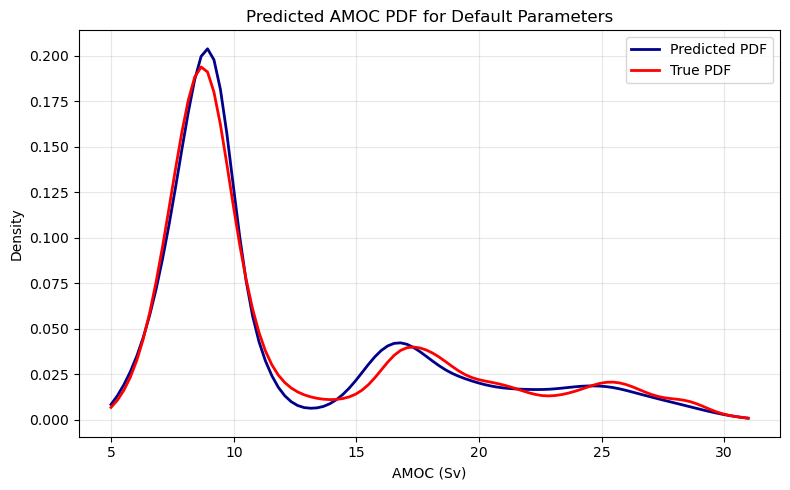

In [11]:
# ----------------------------
# 1. Define default parameter vector for GP inputs
# ----------------------------
X_new = np.array([[
    1e-05,      # diff_dia_min
    3.0,        # drag_topo_fac
    0.001,      # slope_max
    1500,       # diff_iso
    1500,       # diff_gm
    0.00015     # diff_dia_max
]])
print("X_new shape:", X_new.shape)

# ----------------------------
# 2. Predict PCA components and summary stats using fitted GP emulator
# ----------------------------
pca_pred, Y_pred, pca_std, Y_std = gp_emul.predict(X_new)

print(f"Predicted PCA components shape: {pca_pred.shape}")
print(f"Predicted PCA components: {pca_pred[0]}")

# ----------------------------
# 3. Extract scalar stats
# ----------------------------
print(Y_pred[0])
mean_pred, std_pred, avg_stadial_duration, avg_waiting_time, amplitude, n_stadials_pred = Y_pred[0]
print(f"Predicted avg stadial duration: {avg_stadial_duration:.2f}")
print(f"Predicted avg waiting time: {avg_waiting_time:.2f}")
print(f"Predicted amplitude: {amplitude:.4f}")

# ----------------------------
# 4. Reconstruct PDF from PCA components
# ----------------------------
pdf_pred = gp_emul.reconstruct_pdf(pca_pred)
print(f"Reconstructed PDF shape: {pdf_pred.shape}")

# ----------------------------
# 5. Plot predicted PDF with uncertainty
# ----------------------------
x_grid = default_stats['x_grid']  # use the same grid as PDFs

plt.figure(figsize=(8,5))
plt.plot(x_grid, pdf_pred[0], color='darkblue', label='Predicted PDF', linewidth=2)
plt.plot(x_grid, default_stats['pdf'], color='red', label='True PDF', linewidth=2)
plt.xlabel('AMOC (Sv)')
plt.ylabel('Density')
plt.title('Predicted AMOC PDF for Default Parameters')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, pca_train, pca_test, pdf_train, pdf_test, Y_train, Y_test = train_test_split(
    X, pca_components, pdf_matrix, other_stats, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])
print("PCA train shape:", pca_train.shape, "PCA test shape:", pca_test.shape)
print("PDF train shape:", pdf_train.shape, "PDF test shape:", pdf_test.shape)
print("Y train shape:", Y_train.shape, "Y test shape:", Y_test.shape)

Train size: 257 Test size: 65
PCA train shape: (257, 5) PCA test shape: (65, 5)
PDF train shape: (257, 100) PDF test shape: (65, 100)
Y train shape: (257, 6) Y test shape: (65, 6)


In [13]:
from sklearn.gaussian_process.kernels import Matern

kernel = 1 * Matern(length_scale=1.0, nu=1.5)
gp_emul = GPEmulatorPDF(kernel=kernel)
gp_emul.pca = pca_model  # Use the pre-fitted PCA model
gp_emul.pdf_xpoints = default_stats['x_grid']  # Set the x-grid

gp_emul.fit(X_train, Y_train, pca_train)  # Fit on pre-computed PCA components
print("GP emulator fitted on training set.")
print(f"Predicting {gp_emul.n_pca_components} PCA components + {Y_train.shape[1]} other stats")

GP emulator fitted on training set.
Predicting 5 PCA components + 6 other stats


In [14]:
# Predict PCA components and other stats
pca_pred, Y_pred, pca_std, Y_std = gp_emul.predict(X_test, return_std=True)

# Evaluate PCA component predictions
pca_rmse = np.sqrt(mean_squared_error(pca_test, pca_pred))
print(f"PCA components RMSE: {pca_rmse:.4f}")

# Evaluate each PCA component individually
for i in range(pca_pred.shape[1]):
    rmse = np.sqrt(mean_squared_error(pca_test[:, i], pca_pred[:, i]))
    print(f"  PCA component {i+1} RMSE: {rmse:.4f}")

# Reconstruct PDFs from predicted PCA components
pdf_pred = gp_emul.reconstruct_pdf(pca_pred)

# Evaluate PDF reconstruction
pdf_rmse = np.sqrt(mean_squared_error(pdf_test, pdf_pred))
print(f"\nPDF reconstruction RMSE: {pdf_rmse:.4f}")

# Evaluate other summary statistics
print("\nOther summary statistics:")
for i, name in enumerate(['mean', 'std', 'avg_stadial_duration', 'avg_waiting_time', 'amplitude', 'n_stadials']):
    rmse = np.sqrt(mean_squared_error(Y_test[:, i], Y_pred[:, i]))
    print(f"{name} RMSE: {rmse:.4f}")

PCA components RMSE: 0.0651
  PCA component 1 RMSE: 0.0671
  PCA component 2 RMSE: 0.0605
  PCA component 3 RMSE: 0.0848
  PCA component 4 RMSE: 0.0492
  PCA component 5 RMSE: 0.0585

PDF reconstruction RMSE: 0.0192

Other summary statistics:
mean RMSE: 0.3306
std RMSE: 0.3871
avg_stadial_duration RMSE: 139.2250
avg_waiting_time RMSE: 236.5510
amplitude RMSE: 1.2832
n_stadials RMSE: 5.7654


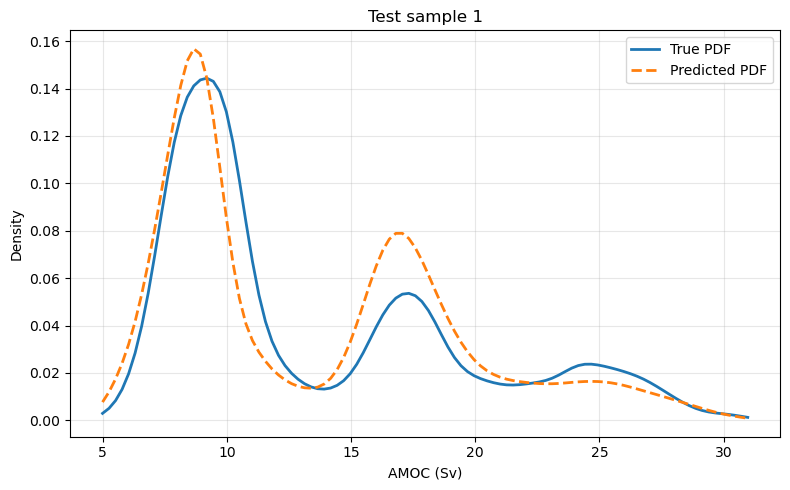

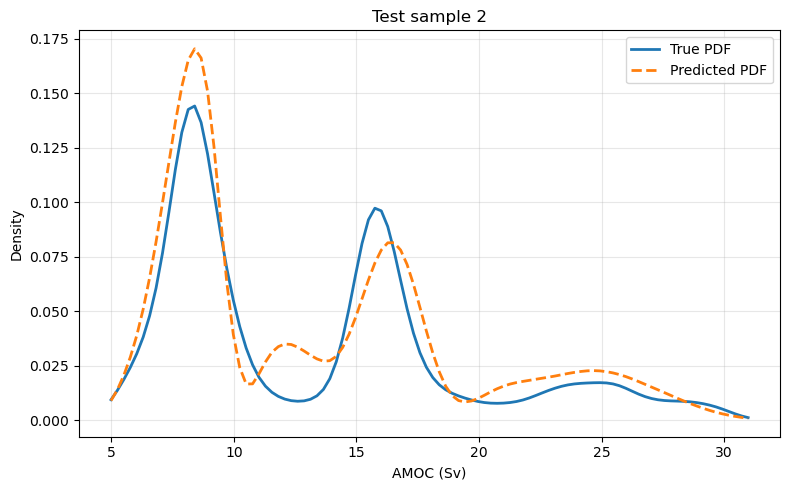

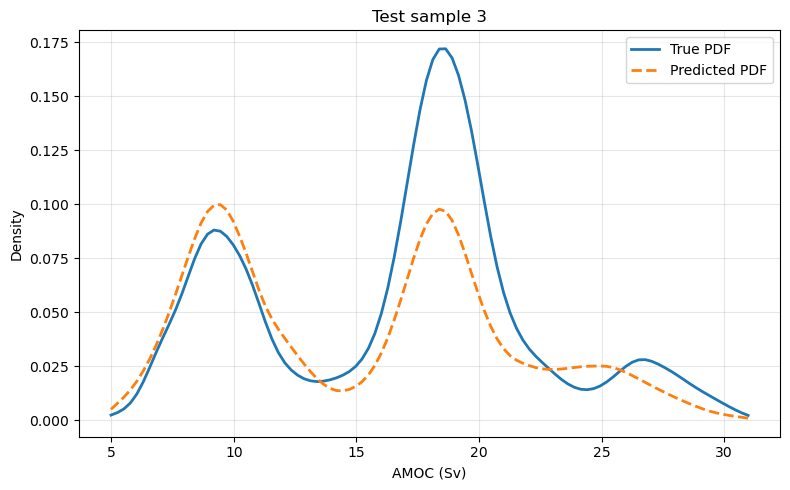

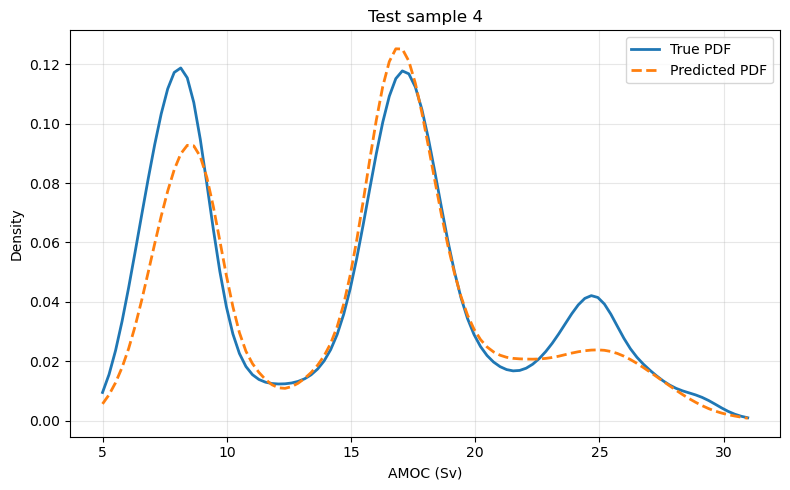

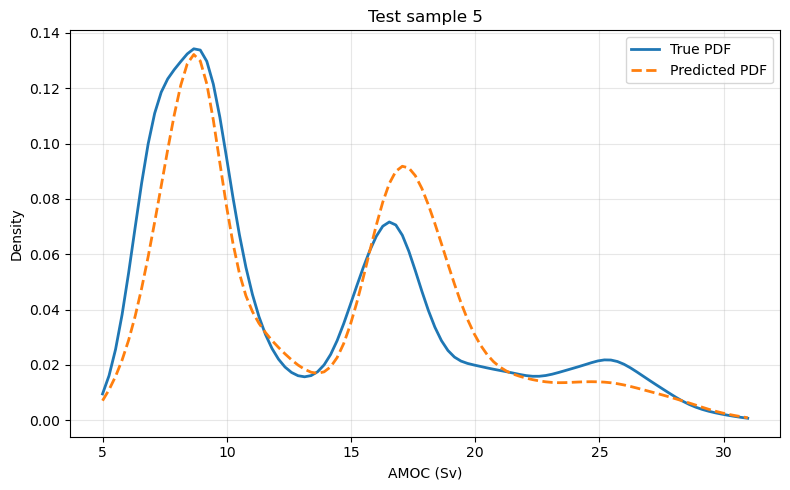

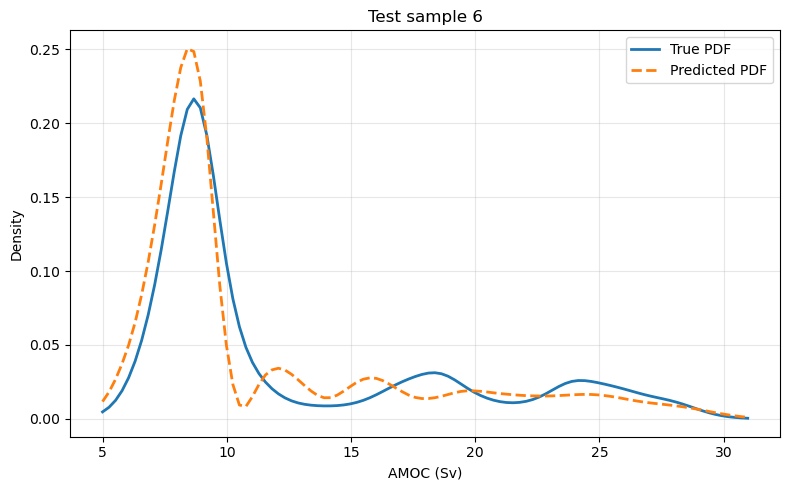

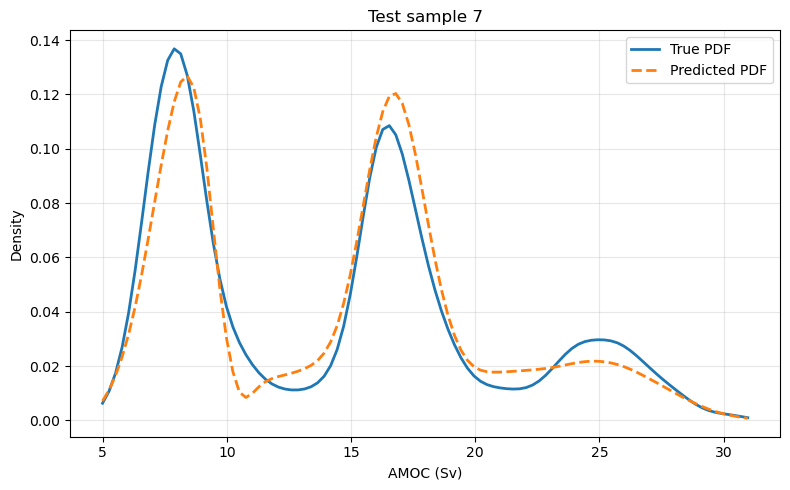

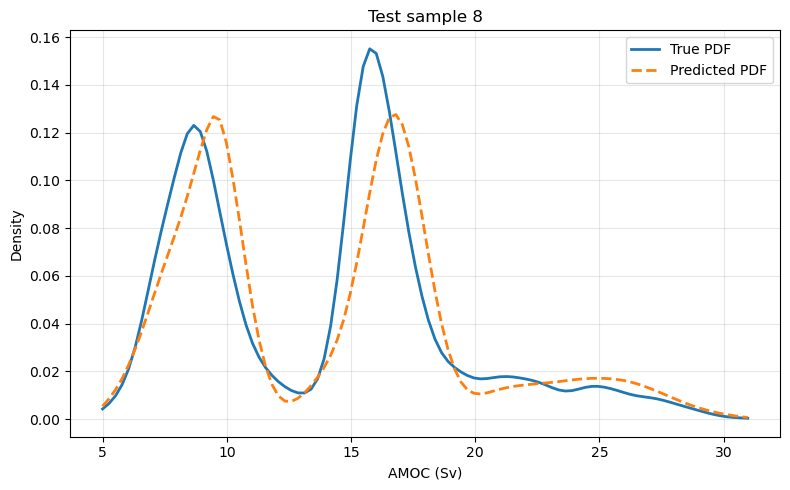

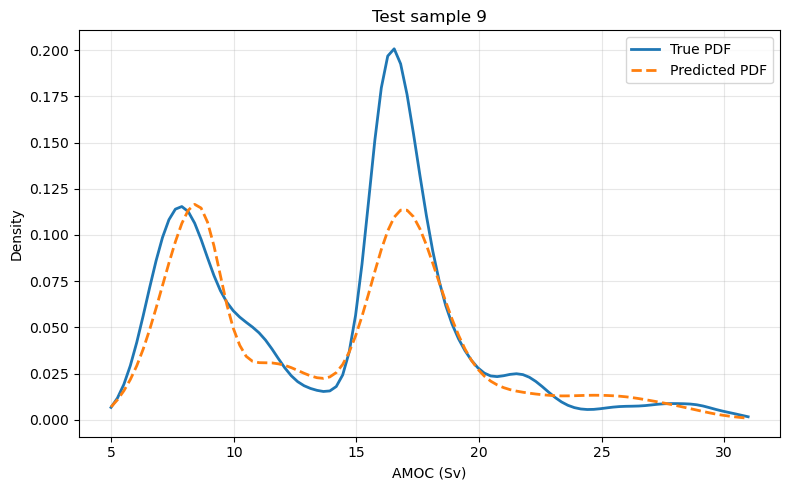

In [15]:
import matplotlib.pyplot as plt

x_grid = default_stats['x_grid']  # Get the x-grid for plotting

for i in range(1, 10):  # plot first 9 test examples (indices 1-9)
    plt.figure(figsize=(8, 5))
    plt.plot(x_grid, pdf_test[i], label='True PDF', linewidth=2)
    plt.plot(x_grid, pdf_pred[i], label='Predicted PDF', linestyle='--', linewidth=2)
    plt.xlabel('AMOC (Sv)')
    plt.ylabel('Density')
    plt.title(f'Test sample {i}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [16]:
def crossvalidation(X, Y, pca_components, pdfs, emulator_class, pca_model, pdf_xpoints, 
                   emulator_params=None, cv=5,
                   output_names=['mean', 'std', 'avg_stadial_duration', 'avg_waiting_time', 'amplitude', 'n_stadials']):
    from sklearn.model_selection import KFold
    from sklearn.metrics import mean_squared_error
    
    if emulator_params is None:
        emulator_params = {}
    
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    
    pca_rmses = []  # RMSE for PCA components
    pdf_rmses = []  # RMSE for reconstructed PDFs
    pdf_sup_diffs = []  # Supremum differences for PDFs
    individual_rmses = {name: [] for name in output_names}
    
    # Track individual PCA component RMSEs
    n_pca = pca_components.shape[1]
    pca_component_rmses = {f'pca_{i+1}': [] for i in range(n_pca)}
    
    for train_idx, test_idx in kf.split(X):
        # Split data
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]  
        pca_train, pca_test = pca_components[train_idx], pca_components[test_idx]
        pdfs_train, pdfs_test = pdfs[train_idx], pdfs[test_idx]
        
        # Fit and predict
        emulator = emulator_class(**emulator_params)
        emulator.pca = pca_model  # Set the PCA model
        emulator.pdf_xpoints = pdf_xpoints  # Set the x-grid
        emulator.fit(X_train, Y_train, pca_train)
        pca_pred, Y_pred = emulator.predict(X_test, return_std=False)
        
        # PCA component metrics
        pca_rmse = np.sqrt(mean_squared_error(pca_test, pca_pred))
        pca_rmses.append(pca_rmse)
        
        # Individual PCA component RMSEs
        for i in range(n_pca):
            rmse = np.sqrt(mean_squared_error(pca_test[:, i], pca_pred[:, i]))
            pca_component_rmses[f'pca_{i+1}'].append(rmse)
        
        # Reconstruct PDFs from predicted PCA components
        pdf_pred = emulator.reconstruct_pdf(pca_pred)
        
        # PDF metrics
        pdf_rmse = np.sqrt(mean_squared_error(pdfs_test.flatten(), pdf_pred.flatten()))
        pdf_rmses.append(pdf_rmse)
        
        # PDF supremum difference (max pointwise error across all test PDFs)
        pdf_pointwise_errors = np.abs(pdfs_test - pdf_pred)  # shape: (n_test, n_grid_points)
        pdf_sup_diff = np.max(pdf_pointwise_errors)  # maximum error over all points and all test samples
        pdf_sup_diffs.append(pdf_sup_diff)
        
        # Individual summary statistics RMSEs
        for i, name in enumerate(output_names):
            if i < Y_test.shape[1]:
                rmse = np.sqrt(mean_squared_error(Y_test[:, i], Y_pred[:, i]))
                individual_rmses[name].append(rmse)
    
    # Prepare results
    results = {
        'pca': {
            'rmse_mean': np.mean(pca_rmses),
            'rmse_std': np.std(pca_rmses),
            'rmse_scores': pca_rmses
        },
        'pdf': {
            'rmse_mean': np.mean(pdf_rmses),
            'rmse_std': np.std(pdf_rmses),
            'rmse_scores': pdf_rmses,
            'sup_diff_mean': np.mean(pdf_sup_diffs),
            'sup_diff_std': np.std(pdf_sup_diffs),
            'sup_diff_scores': pdf_sup_diffs
        }
    }
    
    # Add individual PCA component results
    for pca_name in pca_component_rmses.keys():
        if len(pca_component_rmses[pca_name]) > 0:
            results[pca_name] = {
                'mean': np.mean(pca_component_rmses[pca_name]),
                'std': np.std(pca_component_rmses[pca_name]),
                'scores': pca_component_rmses[pca_name]
            }
    
    # Add other summary statistics results
    for name in output_names:
        if len(individual_rmses[name]) > 0:
            results[name] = {
                'mean': np.mean(individual_rmses[name]),
                'std': np.std(individual_rmses[name]),
                'scores': individual_rmses[name]
            }
    
    return results

In [17]:
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel

kernel = (
    ConstantKernel(1.0, constant_value_bounds=(0.01, 100.0)) * 
    (RBF(length_scale=[1.0]*6, length_scale_bounds=(0.1, 10.0)) + 
     Matern(length_scale=[1.0]*6, length_scale_bounds=(0.1, 10.0), nu=2.5)) 
    + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-2))
)

kernel_matern = 1 * Matern(length_scale=1.0, nu=1.5)

emulator_params = {
    'kernel': kernel_matern
}

cv_results = crossvalidation(
    X=X, 
    Y=other_stats, 
    pca_components=pca_components,
    pdfs=pdf_matrix, 
    emulator_class=GPEmulatorPDF,
    pca_model=pca_model,
    pdf_xpoints=default_stats['x_grid'],
    emulator_params=emulator_params, 
    cv=5,
    output_names=['mean', 'std', 'avg_stadial_duration', 'avg_waiting_time', 'amplitude', 'n_stadials']
)

# Print PCA component results
print("=== PCA Component Predictions ===")
print(f"Overall PCA RMSE: {cv_results['pca']['rmse_mean']:.4f} ± {cv_results['pca']['rmse_std']:.4f}")
for i in range(pca_components.shape[1]):
    pca_key = f'pca_{i+1}'
    if pca_key in cv_results:
        print(f"  {pca_key} RMSE: {cv_results[pca_key]['mean']:.4f} ± {cv_results[pca_key]['std']:.4f}")

# Print PDF reconstruction results
print("\n=== PDF Reconstruction ===")
print(f"PDF RMSE: {cv_results['pdf']['rmse_mean']:.4f} ± {cv_results['pdf']['rmse_std']:.4f}")
print(f"PDF Sup Diff: {cv_results['pdf']['sup_diff_mean']:.4f} ± {cv_results['pdf']['sup_diff_std']:.4f}")

# Print other summary statistics
print("\n=== Other Summary Statistics ===")
print(f"Mean RMSE: {cv_results['mean']['mean']:.4f} ± {cv_results['mean']['std']:.4f}")
print(f"Std RMSE: {cv_results['std']['mean']:.4f} ± {cv_results['std']['std']:.4f}")
print(f"Stadial duration RMSE: {cv_results['avg_stadial_duration']['mean']:.4f} ± {cv_results['avg_stadial_duration']['std']:.4f}")
print(f"Waiting time RMSE: {cv_results['avg_waiting_time']['mean']:.4f} ± {cv_results['avg_waiting_time']['std']:.4f}")
print(f"Amplitude RMSE: {cv_results['amplitude']['mean']:.4f} ± {cv_results['amplitude']['std']:.4f}")
print(f"N stadials RMSE: {cv_results['n_stadials']['mean']:.4f} ± {cv_results['n_stadials']['std']:.4f}")

=== PCA Component Predictions ===
Overall PCA RMSE: 0.0807 ± 0.0142
  pca_1 RMSE: 0.0942 ± 0.0230
  pca_2 RMSE: 0.0846 ± 0.0190
  pca_3 RMSE: 0.0791 ± 0.0083
  pca_4 RMSE: 0.0719 ± 0.0320
  pca_5 RMSE: 0.0637 ± 0.0084

=== PDF Reconstruction ===
PDF RMSE: 0.0218 ± 0.0026
PDF Sup Diff: 0.2325 ± 0.0621

=== Other Summary Statistics ===
Mean RMSE: 0.4506 ± 0.1252
Std RMSE: 0.4218 ± 0.0424
Stadial duration RMSE: 162.4228 ± 25.6379
Waiting time RMSE: 280.3384 ± 45.1081
Amplitude RMSE: 1.3700 ± 0.2703
N stadials RMSE: 6.9388 ± 1.4412


GP emulator fitted on training set.
Predicting 5 PCA components + 6 other stats

PCA EMULATOR EVALUATION SUMMARY

Overall PCA components:
  RMSE: 0.0651
  R²:   0.7732

Individual PCA component metrics:
  PCA 1: RMSE=0.0671, R²=0.8916, MAE=0.0505
  PCA 2: RMSE=0.0605, R²=0.8220, MAE=0.0438
  PCA 3: RMSE=0.0848, R²=0.4802, MAE=0.0647
  PCA 4: RMSE=0.0492, R²=0.3391, MAE=0.0344
  PCA 5: RMSE=0.0585, R²=0.2135, MAE=0.0457

PDF reconstruction:
  RMSE: 0.0192
  MAE:  0.0115

Other summary statistics:
  mean: RMSE=0.3306, R²=0.9563, MAE=0.2185
  std: RMSE=0.3871, R²=0.8187, MAE=0.3077
  avg_stadial_duration: RMSE=139.2250, R²=0.8675, MAE=96.6799
  avg_waiting_time: RMSE=236.5510, R²=0.5622, MAE=186.4626
  amplitude: RMSE=1.2832, R²=0.8376, MAE=1.0033
  n_stadials: RMSE=5.7654, R²=0.6263, MAE=4.6561


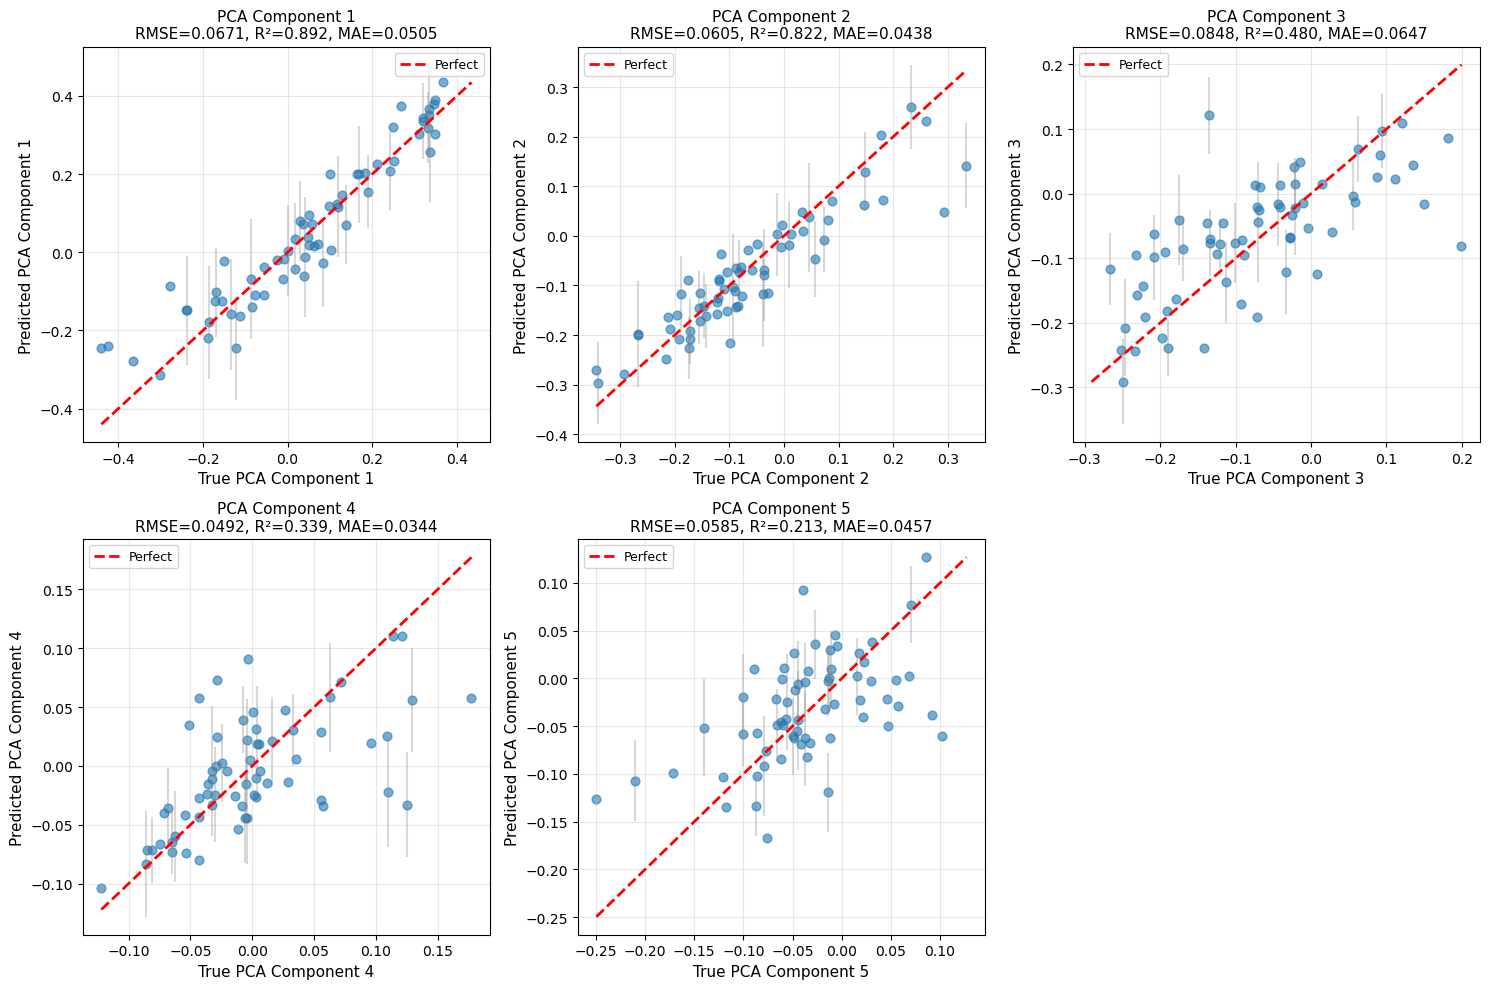

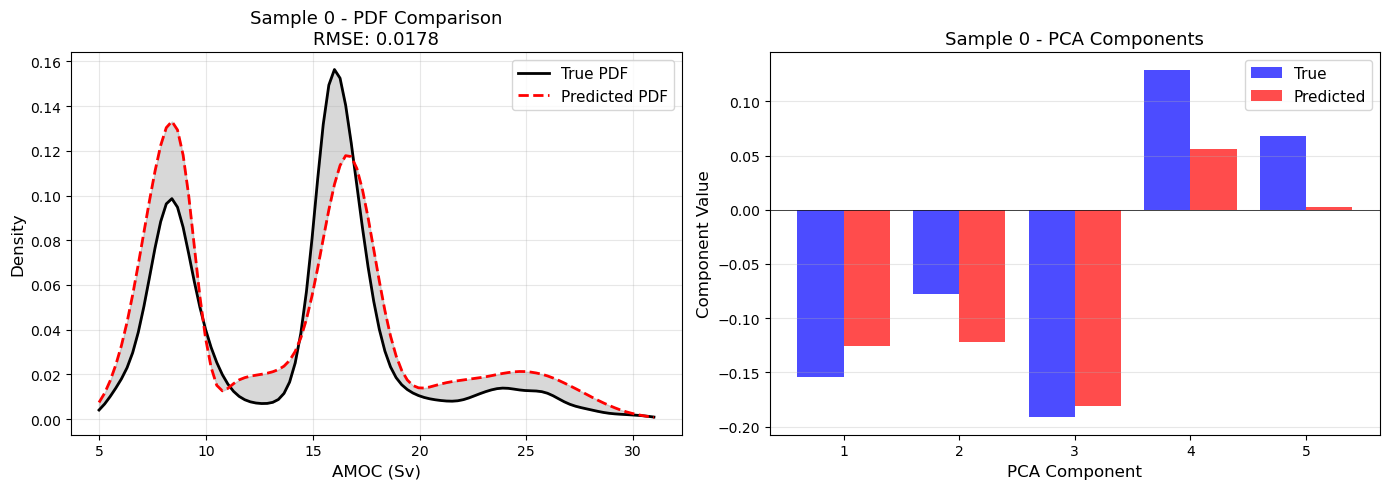

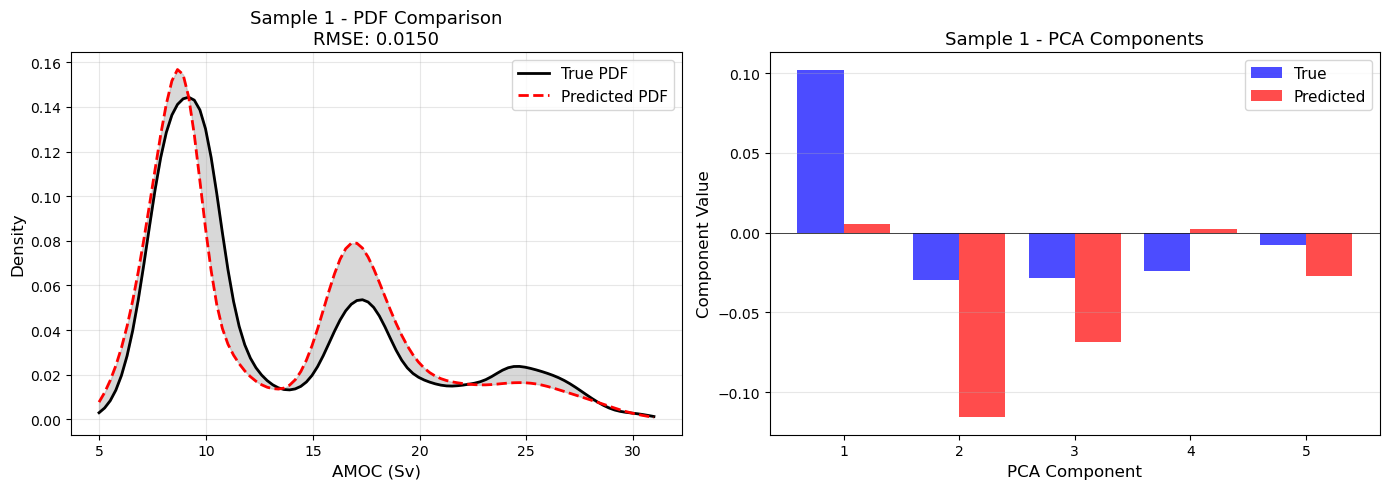

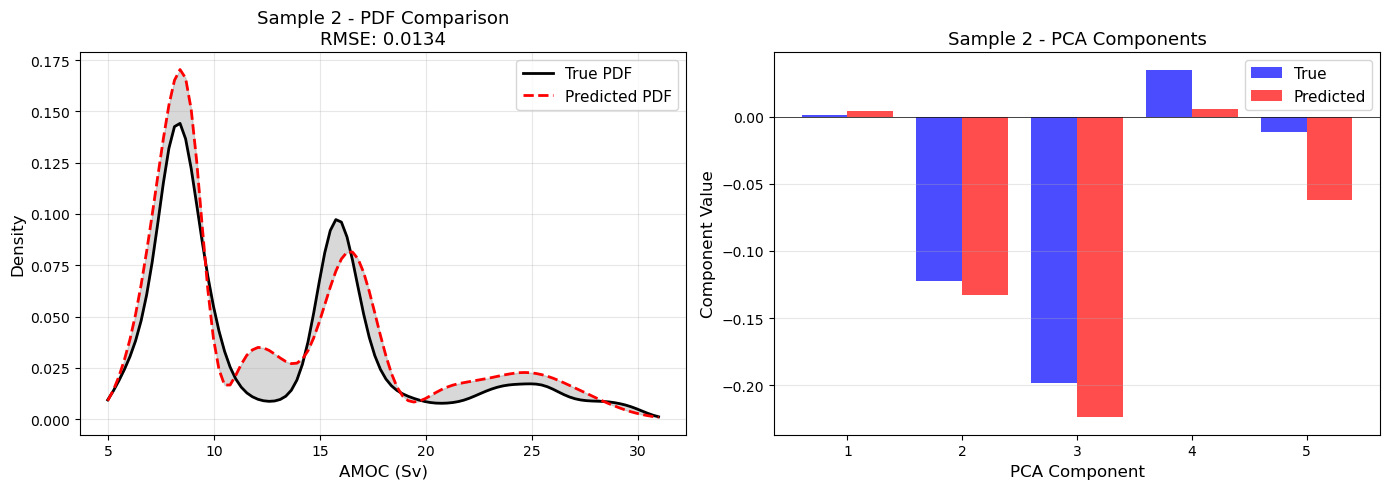

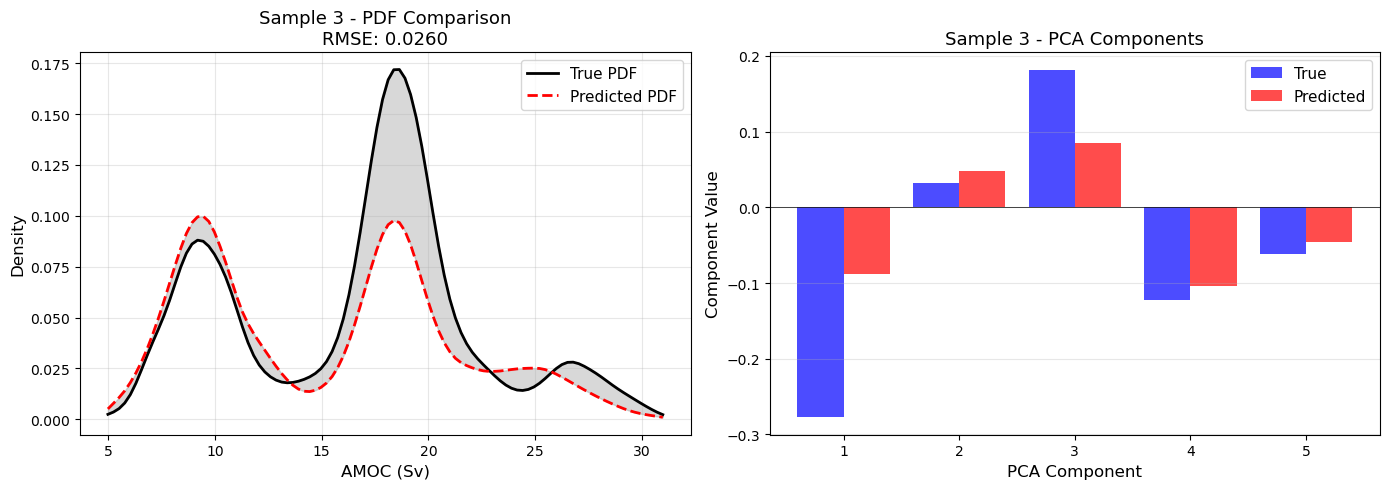

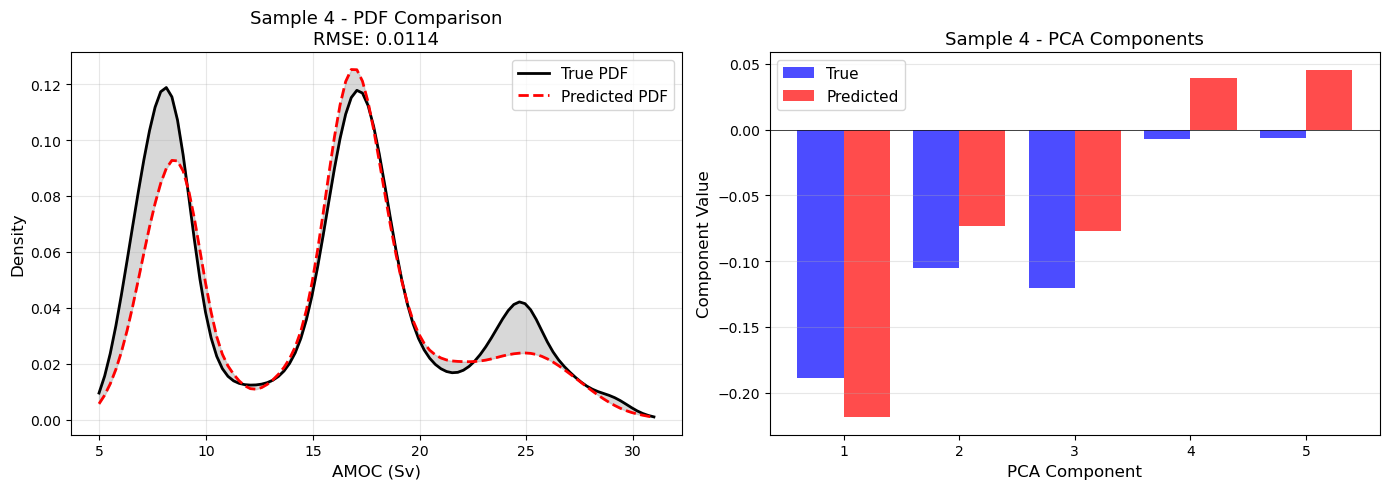

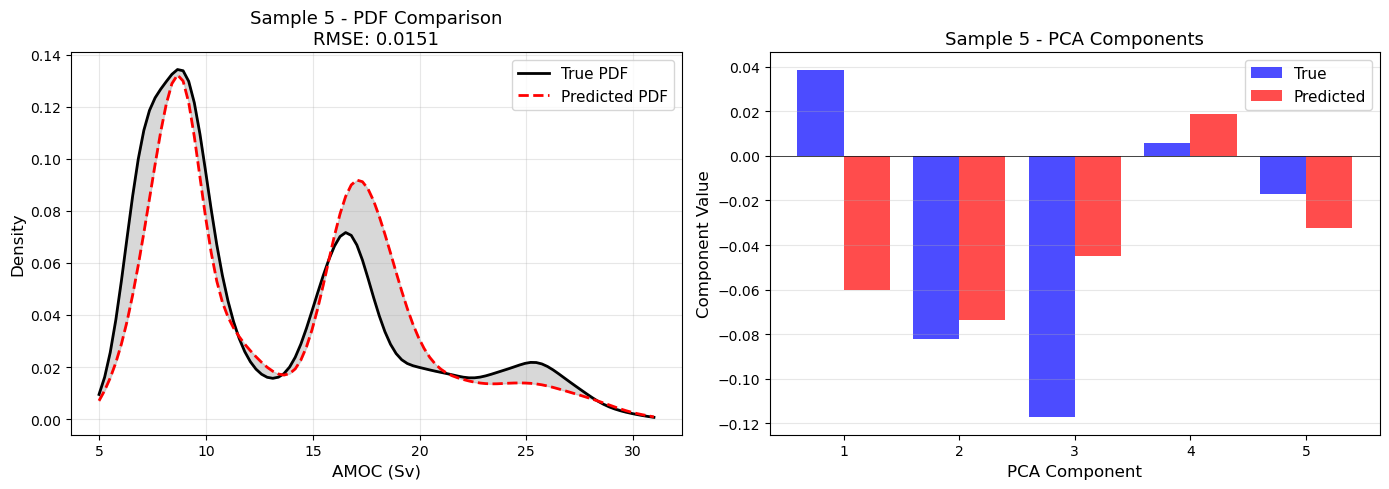

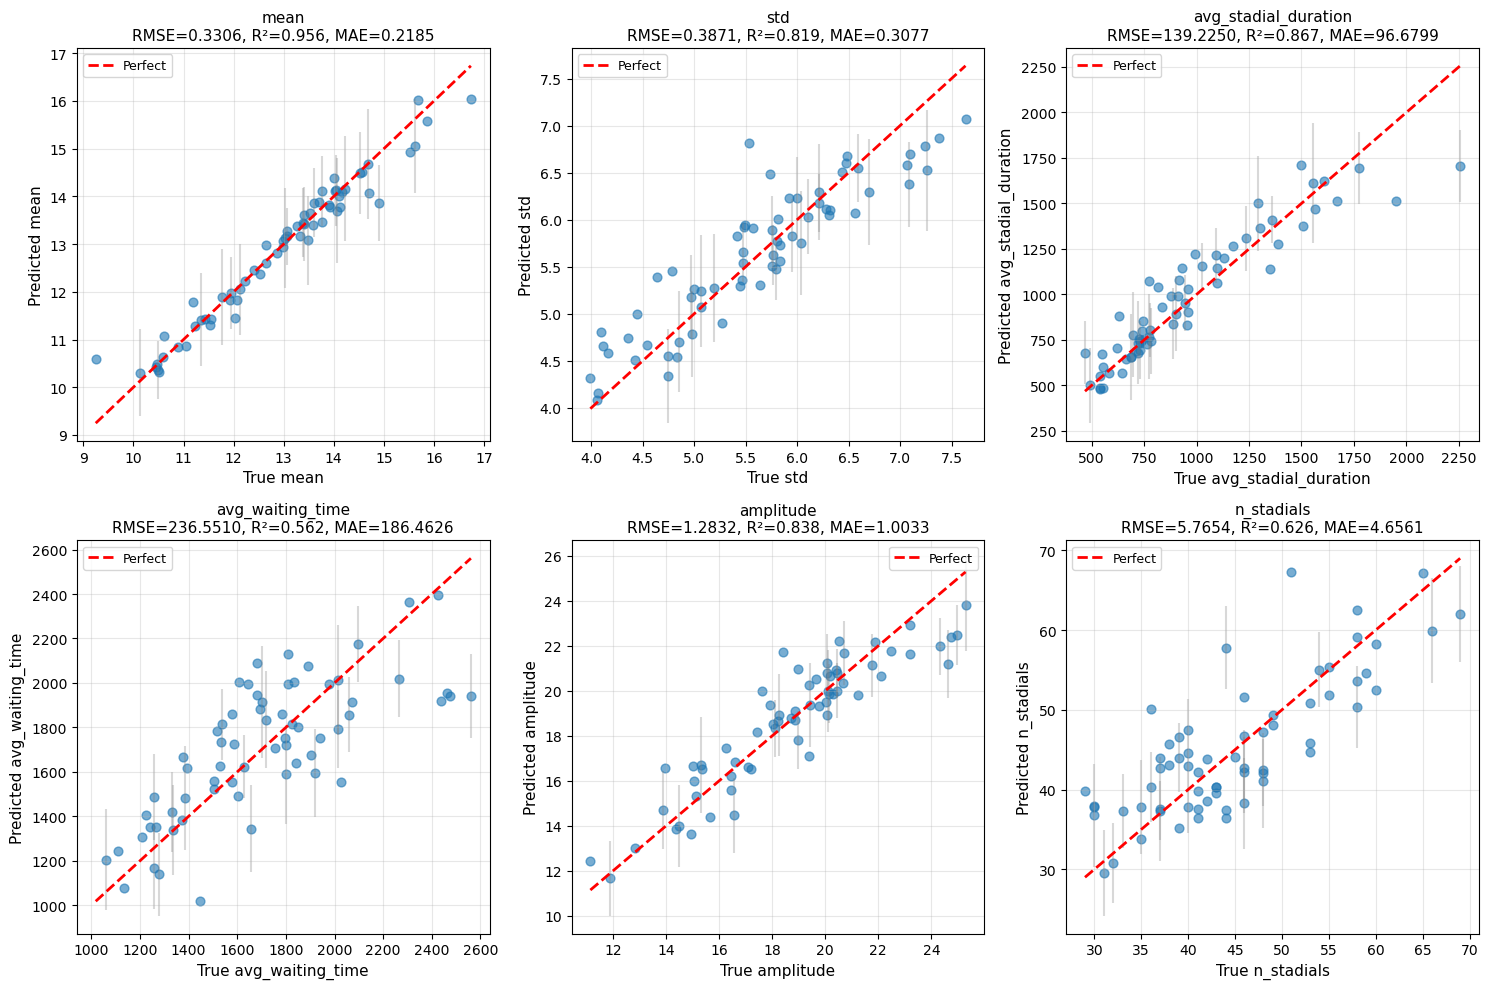

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process.kernels import Matern
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Train-test split
X_train, X_test, pca_train, pca_test, pdf_train, pdf_test, Y_train, Y_test = train_test_split(
    X, pca_components, pdf_matrix, other_stats, test_size=0.2, random_state=42
)

# Train emulator
kernel = 1 * Matern(length_scale=1.0, nu=1.5)
gp_emul = GPEmulatorPDF(kernel=kernel)
gp_emul.pca = pca_model  # Set pre-fitted PCA model
gp_emul.pdf_xpoints = default_stats['x_grid']
gp_emul.fit(X_train, Y_train, pca_train)

print("GP emulator fitted on training set.")
print(f"Predicting {gp_emul.n_pca_components} PCA components + {Y_train.shape[1]} other stats")

# Predict
pca_pred, Y_pred, pca_std, Y_std = gp_emul.predict(X_test, return_std=True)

# Reconstruct PDFs
pdf_pred = gp_emul.reconstruct_pdf(pca_pred)

print("\n" + "="*70)
print("PCA EMULATOR EVALUATION SUMMARY")
print("="*70)

# Overall PCA component metrics
pca_rmse = np.sqrt(mean_squared_error(pca_test, pca_pred))
pca_r2 = r2_score(pca_test.flatten(), pca_pred.flatten())
print(f"\nOverall PCA components:")
print(f"  RMSE: {pca_rmse:.4f}")
print(f"  R²:   {pca_r2:.4f}")

# Individual PCA component metrics
print(f"\nIndividual PCA component metrics:")
for i in range(pca_pred.shape[1]):
    rmse = np.sqrt(mean_squared_error(pca_test[:, i], pca_pred[:, i]))
    r2 = r2_score(pca_test[:, i], pca_pred[:, i])
    mae = np.mean(np.abs(pca_test[:, i] - pca_pred[:, i]))
    print(f"  PCA {i+1}: RMSE={rmse:.4f}, R²={r2:.4f}, MAE={mae:.4f}")

# PDF reconstruction metrics
pdf_rmse = np.sqrt(mean_squared_error(pdf_test, pdf_pred))
pdf_mae = np.mean(np.abs(pdf_test - pdf_pred))
print(f"\nPDF reconstruction:")
print(f"  RMSE: {pdf_rmse:.4f}")
print(f"  MAE:  {pdf_mae:.4f}")

# Summary statistics metrics
stat_names = ['mean', 'std', 'avg_stadial_duration', 'avg_waiting_time', 'amplitude', 'n_stadials']
print(f"\nOther summary statistics:")
for i, name in enumerate(stat_names):
    rmse = np.sqrt(mean_squared_error(Y_test[:, i], Y_pred[:, i]))
    r2 = r2_score(Y_test[:, i], Y_pred[:, i])
    mae = np.mean(np.abs(Y_test[:, i] - Y_pred[:, i]))
    print(f"  {name}: RMSE={rmse:.4f}, R²={r2:.4f}, MAE={mae:.4f}")

print("="*70)

# ============================================================================
# PLOTTING FUNCTIONS
# ============================================================================

def plot_pca_component_predictions(pca_test, pca_pred, pca_std=None, save_prefix=None):
    """
    Plot true vs predicted for all PCA components.
    """
    n_components = pca_test.shape[1]
    
    # Calculate grid dimensions
    n_cols = 3
    n_rows = int(np.ceil(n_components / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_components > 1 else [axes]
    
    for i in range(n_components):
        ax = axes[i]
        
        true_vals = pca_test[:, i]
        pred_vals = pca_pred[:, i]
        
        # Scatter plot
        ax.scatter(true_vals, pred_vals, alpha=0.6, s=40)
        
        # Perfect prediction line
        min_val = min(true_vals.min(), pred_vals.min())
        max_val = max(true_vals.max(), pred_vals.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', 
               linewidth=2, label='Perfect', zorder=5)
        
        # Add error bars if uncertainties provided
        if pca_std is not None:
            uncertainties = pca_std[:, i]
            n_errorbar_samples = min(20, len(true_vals))
            sample_indices = np.random.choice(len(true_vals), n_errorbar_samples, replace=False)
            ax.errorbar(true_vals[sample_indices], pred_vals[sample_indices], 
                       yerr=uncertainties[sample_indices], 
                       fmt='none', ecolor='gray', alpha=0.3, zorder=1)
        
        # Compute metrics
        rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
        r2 = r2_score(true_vals, pred_vals)
        mae = np.mean(np.abs(true_vals - pred_vals))
        
        # Labels and title
        ax.set_xlabel(f'True PCA Component {i+1}', fontsize=11)
        ax.set_ylabel(f'Predicted PCA Component {i+1}', fontsize=11)
        ax.set_title(f'PCA Component {i+1}\nRMSE={rmse:.4f}, R²={r2:.3f}, MAE={mae:.4f}', 
                    fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    
    # Hide unused subplots
    for i in range(n_components, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    
    if save_prefix:
        plt.savefig(f'{save_prefix}_pca_components.png', dpi=150, bbox_inches='tight')
    
    plt.show()


def plot_pca_uncertainty_calibration(pca_test, pca_pred, pca_std, save_prefix=None):
    """
    Plot prediction error vs uncertainty for PCA components.
    """
    n_components = pca_test.shape[1]
    
    # Calculate grid dimensions
    n_cols = 3
    n_rows = int(np.ceil(n_components / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_components > 1 else [axes]
    
    for i in range(n_components):
        ax = axes[i]
        
        errors = np.abs(pca_test[:, i] - pca_pred[:, i])
        uncertainties = pca_std[:, i]
        
        # Scatter plot
        ax.scatter(uncertainties, errors, alpha=0.6, s=40)
        
        # Ideal calibration line
        max_val = max(uncertainties.max(), errors.max())
        ax.plot([0, max_val], [0, max_val], 'r--', 
               linewidth=2, label='Perfect calibration')
        
        # Compute calibration metric
        within_1sigma = np.sum(errors <= uncertainties) / len(errors)
        
        ax.set_xlabel(f'Predicted Std (PCA {i+1})', fontsize=11)
        ax.set_ylabel(f'Absolute Error (PCA {i+1})', fontsize=11)
        ax.set_title(f'PCA Component {i+1}\n{within_1sigma:.1%} within 1σ', 
                    fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    
    # Hide unused subplots
    for i in range(n_components, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    
    if save_prefix:
        plt.savefig(f'{save_prefix}_pca_uncertainty_calibration.png', dpi=150, bbox_inches='tight')
    
    plt.show()


def plot_pdf_samples_pca(gp_emul, pca_test, pca_pred, pdf_test, pdf_pred, 
                         n_samples=6, save_prefix=None):
    """
    Plot sample PDF reconstructions from PCA components.
    """
    x_grid = gp_emul.pdf_xpoints
    n_samples = min(n_samples, len(pca_test))
    
    for sample_idx in range(n_samples):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Left: PDF comparison
        axes[0].plot(x_grid, pdf_test[sample_idx], label='True PDF', 
                    linewidth=2, color='black')
        axes[0].plot(x_grid, pdf_pred[sample_idx], label='Predicted PDF', 
                    linestyle='--', linewidth=2, color='red')
        axes[0].fill_between(x_grid, pdf_test[sample_idx], pdf_pred[sample_idx], 
                            alpha=0.3, color='gray')
        
        rmse = np.sqrt(np.mean((pdf_test[sample_idx] - pdf_pred[sample_idx])**2))
        axes[0].set_xlabel('AMOC (Sv)', fontsize=12)
        axes[0].set_ylabel('Density', fontsize=12)
        axes[0].set_title(f'Sample {sample_idx} - PDF Comparison\nRMSE: {rmse:.4f}', 
                         fontsize=13)
        axes[0].legend(fontsize=11)
        axes[0].grid(alpha=0.3)
        
        # Right: PCA components comparison
        n_components = pca_test.shape[1]
        x_comp = np.arange(1, n_components + 1)
        
        axes[1].bar(x_comp - 0.2, pca_test[sample_idx], width=0.4, 
                   label='True', alpha=0.7, color='blue')
        axes[1].bar(x_comp + 0.2, pca_pred[sample_idx], width=0.4, 
                   label='Predicted', alpha=0.7, color='red')
        
        axes[1].set_xlabel('PCA Component', fontsize=12)
        axes[1].set_ylabel('Component Value', fontsize=12)
        axes[1].set_title(f'Sample {sample_idx} - PCA Components', fontsize=13)
        axes[1].set_xticks(x_comp)
        axes[1].legend(fontsize=11)
        axes[1].grid(alpha=0.3, axis='y')
        axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        
        plt.tight_layout()
        
        if save_prefix:
            plt.savefig(f'{save_prefix}_sample_{sample_idx}.png', 
                       dpi=150, bbox_inches='tight')
        
        plt.show()


def plot_summary_statistics_pca(Y_test, Y_pred, Y_std=None, stat_names=None, save_prefix=None):
    """
    Plot true vs predicted for summary statistics (same as GMM version).
    """
    n_stats = Y_test.shape[1]
    
    if stat_names is None:
        stat_names = [f'Stat {i+1}' for i in range(n_stats)]
    
    n_cols = 3
    n_rows = int(np.ceil(n_stats / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_stats > 1 else [axes]
    
    for i in range(n_stats):
        ax = axes[i]
        
        true_vals = Y_test[:, i]
        pred_vals = Y_pred[:, i]
        
        ax.scatter(true_vals, pred_vals, alpha=0.6, s=40)
        
        min_val = min(true_vals.min(), pred_vals.min())
        max_val = max(true_vals.max(), pred_vals.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', 
               linewidth=2, label='Perfect', zorder=5)
        
        if Y_std is not None:
            uncertainties = Y_std[:, i]
            n_errorbar_samples = min(20, len(true_vals))
            sample_indices = np.random.choice(len(true_vals), n_errorbar_samples, replace=False)
            ax.errorbar(true_vals[sample_indices], pred_vals[sample_indices], 
                       yerr=uncertainties[sample_indices], 
                       fmt='none', ecolor='gray', alpha=0.3, zorder=1)
        
        rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
        r2 = r2_score(true_vals, pred_vals)
        mae = np.mean(np.abs(true_vals - pred_vals))
        
        ax.set_xlabel(f'True {stat_names[i]}', fontsize=11)
        ax.set_ylabel(f'Predicted {stat_names[i]}', fontsize=11)
        ax.set_title(f'{stat_names[i]}\nRMSE={rmse:.4f}, R²={r2:.3f}, MAE={mae:.4f}', 
                    fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    
    for i in range(n_stats, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    
    if save_prefix:
        plt.savefig(f'{save_prefix}_summary_stats.png', dpi=150, bbox_inches='tight')
    
    plt.show()


# ============================================================================
# Generate all plots
# ============================================================================
save_prefix = "pca_emulator_results"  # or None to not save

# PCA component plots
plot_pca_component_predictions(pca_test, pca_pred, pca_std, save_prefix=save_prefix)

#plot_pca_uncertainty_calibration(pca_test, pca_pred, pca_std, save_prefix=save_prefix)

# PDF sample plots
plot_pdf_samples_pca(gp_emul, pca_test, pca_pred, pdf_test, pdf_pred, 
                     n_samples=6, save_prefix=save_prefix)

# Summary statistics plots
plot_summary_statistics_pca(Y_test, Y_pred, Y_std, stat_names=stat_names,
                           save_prefix=save_prefix)

# MCMC

GP emulator fitted on full dataset.

Target statistics:
  Mean: 12.60 Sv
  Std: 6.13 Sv
  Waiting time: 1391.5 years
  Stadial duration: 904.9 years
  Amplitude: 19.51 Sv
  N stadials: 52

Log posterior at default parameters: -8.1987
Predicted waiting time at default: 1406.0 years (target: 1391.5)
Predicted stadial duration at default: 888.6 years (target: 904.9)

Verifying initial positions...
All walkers have finite posterior ✓

Running MCMC with PDF + waiting time + stadial duration constraints...
Target waiting time: 1391.5 years
Target stadial duration: 904.9 years
Target std: 6.13 Sv


100%|██████████████████████████████████████| 7000/7000 [00:26<00:00, 267.79it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 140;
tau: [383.2598227  419.63003892 402.28563394 468.89579988 524.7986892
 425.33210214]



Posterior samples shape: (19200, 6)

Mean acceptance fraction: 0.215
Acceptance fraction range: [0.103, 0.257]
(Target: 0.2-0.5 for good mixing)

Autocorrelation time: 437.4 steps
Effective number of samples: 44

Generating posterior predictive samples...

POSTERIOR PREDICTIVE CHECK

Target values:
  Mean: 12.60 Sv
  Std: 6.13 Sv
  Waiting time: 1391.5 years
  Stadial duration: 904.9 years
  Amplitude: 19.51 Sv
  N stadials: 52

Posterior predictions (mean ± std):
  Mean: 12.51 ± 0.66 Sv
  Std: 6.20 ± 0.23 Sv
  Stadial duration: 905.3 ± 36.9 years
  Waiting time: 1390.9 ± 21.8 years
  Amplitude: 19.56 ± 0.89 Sv
  N stadials: 52.2 ± 1.2

PDF RMSE: 0.0048 ± 0.0009

POSTERIOR PARAMETER ESTIMATES
Parameter            Mean         Std          Default      2.5%         97.5%       
--------------------------------------------------------------------------------
diff_dia_min         9.537816e-06 1.316407e-06 1.000000e-05 7.591630e-06 1.205506e-05
drag_topo_fac        2.973260e+00 1.444266e-

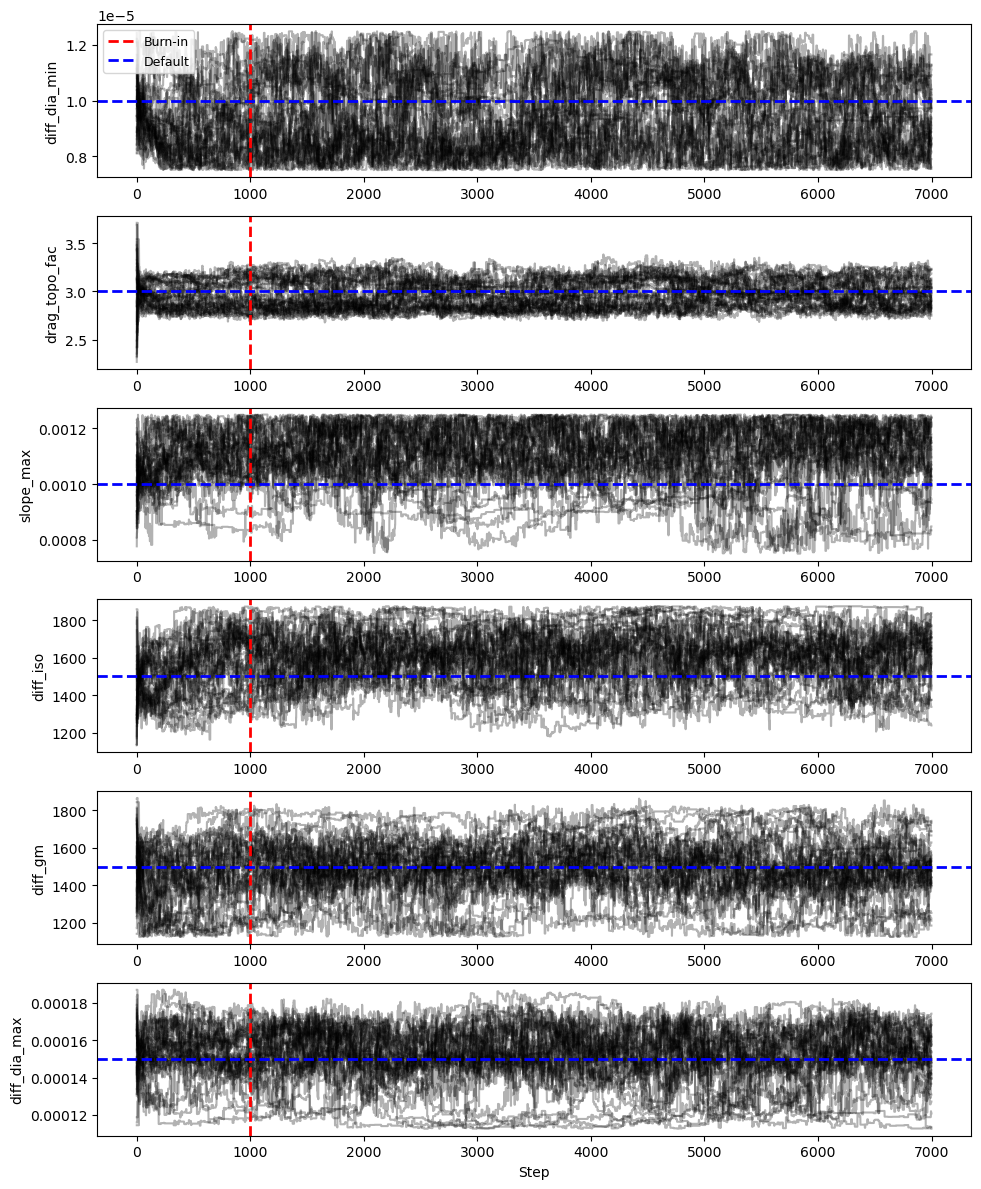

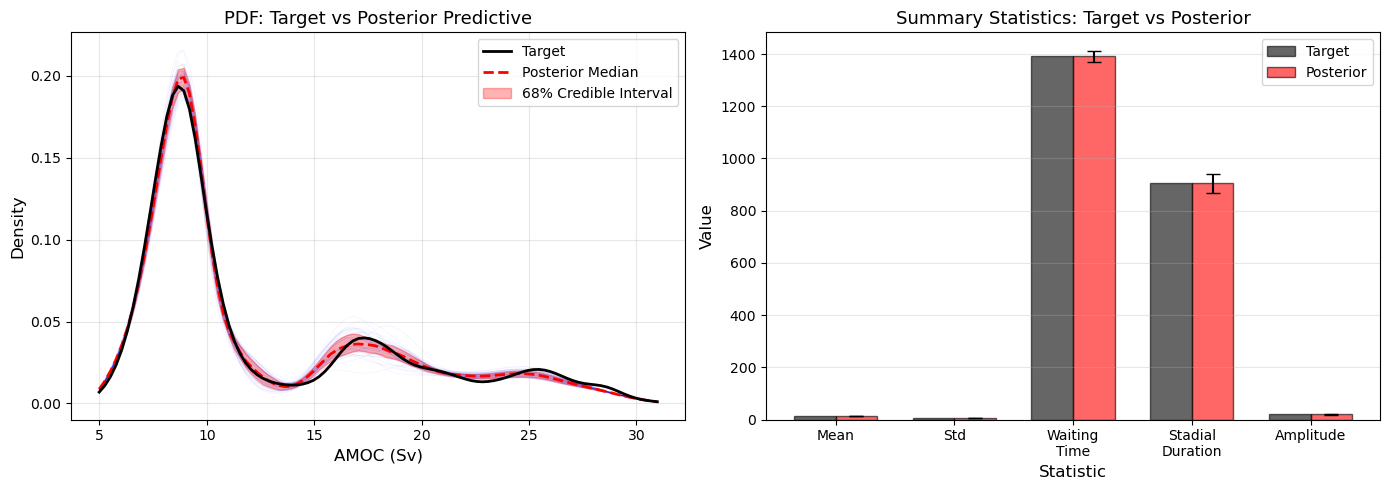

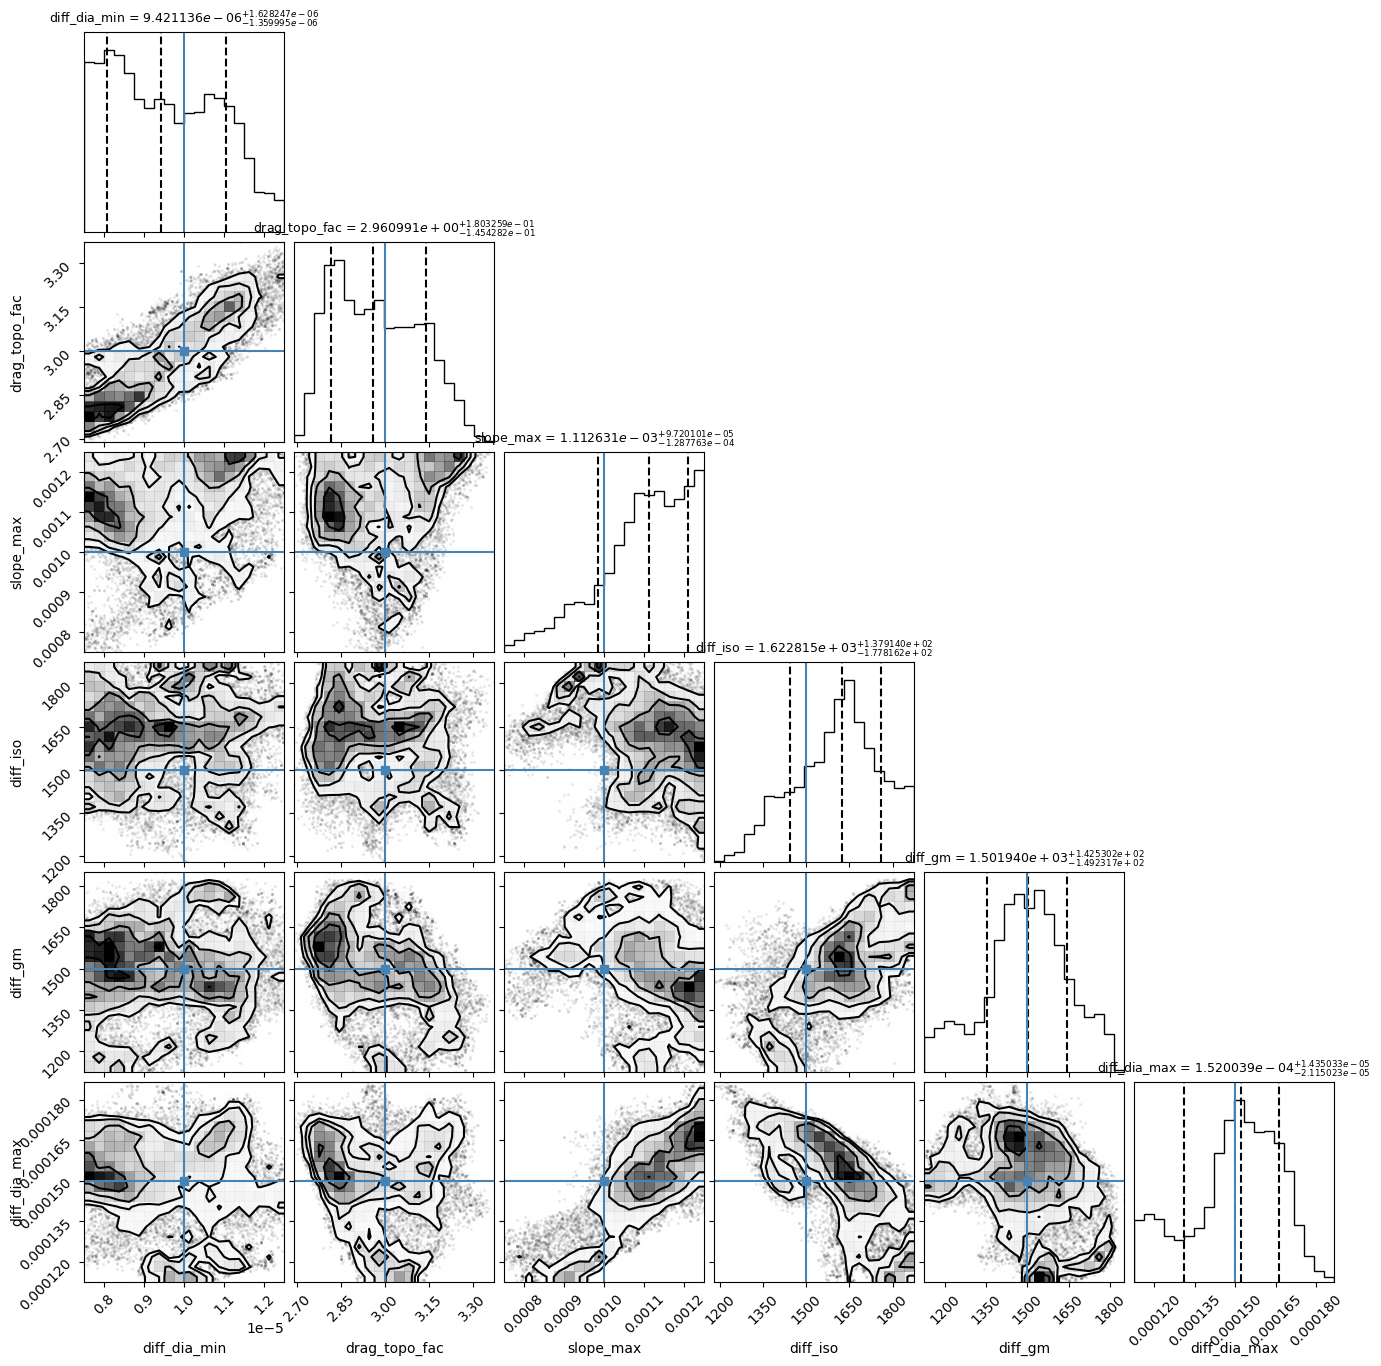


MCMC COMPLETE


In [25]:
import emcee
import numpy as np
from sklearn.gaussian_process.kernels import Matern

# ----------------------------
# Fit emulator on FULL dataset
# ----------------------------
kernel = 1 * Matern(length_scale=1.0, nu=1.5)
gp_emul = GPEmulatorPDF(kernel=kernel)
gp_emul.pca = pca_model  # Set pre-fitted PCA model
gp_emul.pdf_xpoints = default_stats['x_grid']
gp_emul.fit(X, other_stats, pca_components)
print("GP emulator fitted on full dataset.")

# -----------------------------
# 1. Prior bounds (6 parameters)
# -----------------------------
prior_bounds = {
    "diff_dia_min": (7.5e-6, 1.25e-5),
    "drag_topo_fac": (2.25, 3.75),
    "slope_max": (7.5e-4, 1.25e-3),
    "diff_iso": (1125, 1875),
    "diff_gm": (1125, 1875),
    "diff_dia_max": (1.125e-4, 1.875e-4),
}

param_names = list(prior_bounds.keys())
lower_bounds = np.array([b[0] for b in prior_bounds.values()])
upper_bounds = np.array([b[1] for b in prior_bounds.values()])
ndim = len(param_names)

def log_prior(theta):
    theta = np.asarray(theta)
    if np.all((theta >= lower_bounds) & (theta <= upper_bounds)):
        return 0.0
    return -np.inf

# -----------------------------
# 2. Target statistics from default run
# -----------------------------
pdf_target = default_stats['pdf']
x_grid = default_stats['x_grid']
mean_target = default_stats['mean']
std_target = default_stats['std']
waiting_time_target = default_stats['avg_waiting_time']
stadial_duration_target = default_stats['avg_stadial_duration']
amplitude_target = default_stats['avg_amplitude']
n_stadials_target = default_stats['n_stadials']

print(f"\nTarget statistics:")
print(f"  Mean: {mean_target:.2f} Sv")
print(f"  Std: {std_target:.2f} Sv")
print(f"  Waiting time: {waiting_time_target:.1f} years")
print(f"  Stadial duration: {stadial_duration_target:.1f} years")
print(f"  Amplitude: {amplitude_target:.2f} Sv")
print(f"  N stadials: {n_stadials_target:.0f}")

# -----------------------------
# 3. Log-likelihood: PDF + summary statistics
# -----------------------------
# Uncertainty parameters (tune these based on your emulator performance)
sigma_pdf = 0.01            # uncertainty in PDF values (per grid point)
sigma_mean = 0.5            # uncertainty in mean (Sv)
sigma_std = 0.08            # uncertainty in std (Sv)
sigma_waiting = 20.0        # uncertainty in waiting time (years)
sigma_stadial_dur = 50.0    # uncertainty in stadial duration (years)
sigma_amplitude = 1.0       # uncertainty in amplitude (Sv)
sigma_n_stadials = 2.0      # uncertainty in number of stadials

def log_likelihood(theta):
    """
    Compute log-likelihood for matching PDF and summary statistics.
    
    The emulator predicts: 
    - PCA components (which reconstruct to PDF)
    - pred_stats = [mean, std, avg_stadial_duration, avg_waiting_time, avg_amplitude, n_stadials]
    """
    theta = np.array(theta).reshape(1, -1)
    
    # Predict PCA components and stats
    pca_pred, pred_stats = gp_emul.predict(theta, return_std=False)
    
    # Reconstruct PDF from PCA components
    pdf_pred = gp_emul.reconstruct_pdf(pca_pred)
    pdf_pred = pdf_pred.flatten()
    pred_stats = pred_stats.flatten()
    
    # Extract predicted statistics
    pred_mean = pred_stats[0]
    pred_std = pred_stats[1]
    pred_stadial_dur = pred_stats[2]
    pred_waiting = pred_stats[3]
    pred_amplitude = pred_stats[4]
    pred_n_stadials = pred_stats[5]
    
    # Gaussian discrepancy for PDF (integrated over grid)
    # Weight by grid spacing for proper integration
    dx = np.diff(x_grid)
    dx = np.append(dx, dx[-1])  # Extend to match grid length
    pdf_term = -0.5 * np.sum(((pdf_target - pdf_pred)**2) * dx) / sigma_pdf**2
    
    # Gaussian discrepancy for summary statistics
    mean_term = -0.5 * (mean_target - pred_mean)**2 / sigma_mean**2
    std_term = -0.5 * (std_target - pred_std)**2 / sigma_std**2
    waiting_term = -0.5 * (waiting_time_target - pred_waiting)**2 / sigma_waiting**2
    stadial_dur_term = -0.5 * (stadial_duration_target - pred_stadial_dur)**2 / sigma_stadial_dur**2
    amplitude_term = -0.5 * (amplitude_target - pred_amplitude)**2 / sigma_amplitude**2
    n_stadials_term = -0.5 * (n_stadials_target - pred_n_stadials)**2 / sigma_n_stadials**2
    
    # Combine all terms
    log_like = pdf_term + waiting_term #+ stadial_dur_term
    # log_like += mean_term  # uncomment if using
    # log_like += std_term  # uncomment if using
    # log_like += amplitude_term  # uncomment if using
    # log_like += n_stadials_term  # uncomment if using
    
    return log_like


# Alternative: Weighted likelihood with tunable weights
def log_likelihood_weighted(theta, weights=None):
    """
    Weighted log-likelihood allowing control over importance of each component.
    
    Parameters:
    -----------
    theta : array
        Parameter values
    weights : dict, optional
        Weights for each component. Default values emphasize PDF and key stats
    """
    if weights is None:
        weights = {
            'pdf': 1.0,
            'mean': 0.0,
            'std': 0.0,
            'waiting': 1.0,
            'stadial_dur': 1.0,
            'amplitude': 0.0,
            'n_stadials': 0.0
        }
    
    theta = np.array(theta).reshape(1, -1)
    
    # Predict PCA components and stats
    pca_pred, pred_stats = gp_emul.predict(theta, return_std=False)
    
    # Reconstruct PDF
    pdf_pred = gp_emul.reconstruct_pdf(pca_pred).flatten()
    pred_stats = pred_stats.flatten()
    
    # Extract predictions
    pred_mean = pred_stats[0]
    pred_std = pred_stats[1]
    pred_stadial_dur = pred_stats[2]
    pred_waiting = pred_stats[3]
    pred_amplitude = pred_stats[4]
    pred_n_stadials = pred_stats[5]
    
    # Calculate individual terms
    dx = np.diff(x_grid)
    dx = np.append(dx, dx[-1])
    pdf_term = -0.5 * np.sum(((pdf_target - pdf_pred)**2) * dx) / sigma_pdf**2
    
    mean_term = -0.5 * (mean_target - pred_mean)**2 / sigma_mean**2
    std_term = -0.5 * (std_target - pred_std)**2 / sigma_std**2
    waiting_term = -0.5 * (waiting_time_target - pred_waiting)**2 / sigma_waiting**2
    stadial_dur_term = -0.5 * (stadial_duration_target - pred_stadial_dur)**2 / sigma_stadial_dur**2
    amplitude_term = -0.5 * (amplitude_target - pred_amplitude)**2 / sigma_amplitude**2
    n_stadials_term = -0.5 * (n_stadials_target - pred_n_stadials)**2 / sigma_n_stadials**2
    
    # Apply weights
    log_like = (weights['pdf'] * pdf_term + 
                weights['mean'] * mean_term +
                weights['std'] * std_term + 
                weights['waiting'] * waiting_term +
                weights['stadial_dur'] * stadial_dur_term +
                weights['amplitude'] * amplitude_term +
                weights['n_stadials'] * n_stadials_term)
    
    return log_like


# -----------------------------
# 4. Posterior function
# -----------------------------
def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta)
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll

# For weighted version:
def log_posterior_weighted(theta, weights=None):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood_weighted(theta, weights)
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll


# -----------------------------
# 5. Test posterior at default parameters (sanity check)
# -----------------------------
theta_default = np.array([
    1e-05,      # diff_dia_min
    3.0,        # drag_topo_fac
    0.001,      # slope_max
    1500,       # diff_iso
    1500,       # diff_gm
    0.00015     # diff_dia_max
])

log_post_default = log_posterior(theta_default)
print(f"\nLog posterior at default parameters: {log_post_default:.4f}")

# Test prediction at default to verify
pca_test, stats_test = gp_emul.predict(theta_default.reshape(1, -1), return_std=False)
pdf_test = gp_emul.reconstruct_pdf(pca_test).flatten()
print(f"Predicted waiting time at default: {stats_test[0, 3]:.1f} years (target: {waiting_time_target:.1f})")
print(f"Predicted stadial duration at default: {stats_test[0, 2]:.1f} years (target: {stadial_duration_target:.1f})")

# -----------------------------
# 6. Initialize walkers
# -----------------------------
nwalkers = 32
initial_pos = lower_bounds + (upper_bounds - lower_bounds) * np.random.rand(nwalkers, ndim)

# Verify all starting positions have finite posterior
print("\nVerifying initial positions...")
n_bad = 0
for i in range(nwalkers):
    lp = log_posterior(initial_pos[i])
    if not np.isfinite(lp):
        n_bad += 1
if n_bad > 0:
    print(f"Warning: {n_bad}/{nwalkers} walkers have non-finite posterior")
else:
    print("All walkers have finite posterior ✓")

# -----------------------------
# 7. Run MCMC
# -----------------------------
print("\n" + "="*60)
print("Running MCMC with PDF + waiting time + stadial duration constraints...")
print(f"Target waiting time: {waiting_time_target:.1f} years")
print(f"Target stadial duration: {stadial_duration_target:.1f} years")
print(f"Target std: {std_target:.2f} Sv")
print("="*60)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
n_steps = 7000
sampler.run_mcmc(initial_pos, n_steps, progress=True)

# -----------------------------
# 8. Extract posterior samples
# -----------------------------
burn_in = 1000
thin = 10
posterior_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)
print(f"\nPosterior samples shape: {posterior_samples.shape}")

# -----------------------------
# 9. Analyze convergence
# -----------------------------
# Check acceptance fraction
acceptance = sampler.acceptance_fraction
print(f"\nMean acceptance fraction: {np.mean(acceptance):.3f}")
print(f"Acceptance fraction range: [{np.min(acceptance):.3f}, {np.max(acceptance):.3f}]")
print("(Target: 0.2-0.5 for good mixing)")

# Autocorrelation time (if enough steps)
try:
    tau = sampler.get_autocorr_time(quiet=True)
    print(f"\nAutocorrelation time: {np.mean(tau):.1f} steps")
    print(f"Effective number of samples: {posterior_samples.shape[0] / np.mean(tau):.0f}")
except:
    print("\nCould not compute autocorrelation time (may need more steps)")

# -----------------------------
# 10. Posterior predictive check
# -----------------------------
# Sample random parameters from posterior
n_check = 100
random_idx = np.random.choice(len(posterior_samples), size=n_check, replace=False)
check_samples = posterior_samples[random_idx]

# Get predictions for these samples
pred_pdfs_list = []
pred_stats_list = []

print("\nGenerating posterior predictive samples...")
for theta in check_samples:
    theta_reshaped = theta.reshape(1, -1)
    pca_pred, pred_stats = gp_emul.predict(theta_reshaped, return_std=False)
    pdf_pred = gp_emul.reconstruct_pdf(pca_pred)
    pred_pdfs_list.append(pdf_pred.flatten())
    pred_stats_list.append(pred_stats.flatten())

pred_pdfs_array = np.array(pred_pdfs_list)
pred_stats_array = np.array(pred_stats_list)

# Print posterior predictive statistics
print("\n" + "="*60)
print("POSTERIOR PREDICTIVE CHECK")
print("="*60)
print(f"\nTarget values:")
print(f"  Mean: {mean_target:.2f} Sv")
print(f"  Std: {std_target:.2f} Sv")
print(f"  Waiting time: {waiting_time_target:.1f} years")
print(f"  Stadial duration: {stadial_duration_target:.1f} years")
print(f"  Amplitude: {amplitude_target:.2f} Sv")
print(f"  N stadials: {n_stadials_target:.0f}")

print(f"\nPosterior predictions (mean ± std):")
print(f"  Mean: {pred_stats_array[:, 0].mean():.2f} ± {pred_stats_array[:, 0].std():.2f} Sv")
print(f"  Std: {pred_stats_array[:, 1].mean():.2f} ± {pred_stats_array[:, 1].std():.2f} Sv")
print(f"  Stadial duration: {pred_stats_array[:, 2].mean():.1f} ± {pred_stats_array[:, 2].std():.1f} years")
print(f"  Waiting time: {pred_stats_array[:, 3].mean():.1f} ± {pred_stats_array[:, 3].std():.1f} years")
print(f"  Amplitude: {pred_stats_array[:, 4].mean():.2f} ± {pred_stats_array[:, 4].std():.2f} Sv")
print(f"  N stadials: {pred_stats_array[:, 5].mean():.1f} ± {pred_stats_array[:, 5].std():.1f}")

# PDF RMSE
pdf_rmse_samples = [np.sqrt(np.mean((pdf_target - pred_pdfs_array[i])**2)) 
                    for i in range(len(pred_pdfs_array))]
print(f"\nPDF RMSE: {np.mean(pdf_rmse_samples):.4f} ± {np.std(pdf_rmse_samples):.4f}")

# -----------------------------
# 11. Parameter posterior statistics
# -----------------------------
print("\n" + "="*60)
print("POSTERIOR PARAMETER ESTIMATES")
print("="*60)
print(f"{'Parameter':<20} {'Mean':<12} {'Std':<12} {'Default':<12} {'2.5%':<12} {'97.5%':<12}")
print("-" * 80)
for i, name in enumerate(param_names):
    mean_val = np.mean(posterior_samples[:, i])
    std_val = np.std(posterior_samples[:, i])
    default_val = theta_default[i]
    lower_ci = np.percentile(posterior_samples[:, i], 2.5)
    upper_ci = np.percentile(posterior_samples[:, i], 97.5)
    print(f"{name:<20} {mean_val:<12.6e} {std_val:<12.6e} {default_val:<12.6e} {lower_ci:<12.6e} {upper_ci:<12.6e}")

# -----------------------------
# 12. Visualize results
# -----------------------------
import matplotlib.pyplot as plt

# Trace plots
fig, axes = plt.subplots(ndim, 1, figsize=(10, 2*ndim))
samples_chain = sampler.get_chain()

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples_chain[:, :, i], alpha=0.3, color='black')
    ax.axvline(burn_in, color='red', linestyle='--', linewidth=2, label='Burn-in' if i == 0 else '')
    ax.axhline(theta_default[i], color='blue', linestyle='--', linewidth=2, label='Default' if i == 0 else '')
    ax.set_ylabel(param_names[i], fontsize=10)
    if i == 0:
        ax.legend(fontsize=9)
    if i == ndim - 1:
        ax.set_xlabel('Step')

plt.tight_layout()
plt.savefig('mcmc_traces_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# PDF comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDF with posterior uncertainty
ax = axes[0]
pred_pdf_median = np.median(pred_pdfs_array, axis=0)
pred_pdf_lower = np.percentile(pred_pdfs_array, 16, axis=0)
pred_pdf_upper = np.percentile(pred_pdfs_array, 84, axis=0)

ax.plot(x_grid, pdf_target, 'k-', linewidth=2, label='Target', zorder=10)
ax.plot(x_grid, pred_pdf_median, 'r--', linewidth=2, label='Posterior Median', zorder=9)
ax.fill_between(x_grid, pred_pdf_lower, pred_pdf_upper, 
                alpha=0.3, color='red', label='68% Credible Interval')

# Plot some posterior samples
for i in range(min(50, len(pred_pdfs_array))):
    ax.plot(x_grid, pred_pdfs_array[i], 'b-', alpha=0.05, linewidth=0.5)

ax.set_xlabel('AMOC (Sv)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('PDF: Target vs Posterior Predictive', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: Summary statistics comparison
ax = axes[1]
stat_names = ['Mean', 'Std', 'Waiting\nTime', 'Stadial\nDuration', 'Amplitude']
target_vals = [mean_target, std_target, waiting_time_target, 
               stadial_duration_target, amplitude_target]
pred_means = [pred_stats_array[:, 0].mean(), pred_stats_array[:, 1].mean(),
              pred_stats_array[:, 3].mean(), pred_stats_array[:, 2].mean(),
              pred_stats_array[:, 4].mean()]
pred_stds = [pred_stats_array[:, 0].std(), pred_stats_array[:, 1].std(),
             pred_stats_array[:, 3].std(), pred_stats_array[:, 2].std(),
             pred_stats_array[:, 4].std()]

x_pos = np.arange(len(stat_names))
width = 0.35

ax.bar(x_pos - width/2, target_vals, width, label='Target', 
       color='black', alpha=0.6, edgecolor='black')
ax.bar(x_pos + width/2, pred_means, width, yerr=pred_stds, capsize=5,
       label='Posterior', color='red', alpha=0.6, edgecolor='black')

ax.set_xlabel('Statistic', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Summary Statistics: Target vs Posterior', fontsize=13)
ax.set_xticks(x_pos)
ax.set_xticklabels(stat_names, fontsize=10)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('mcmc_predictions_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# Corner plot
try:
    import corner
    
    fig = corner.corner(
        posterior_samples,
        labels=param_names,
        truths=theta_default,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt='.6e',
        title_kwargs={'fontsize': 9}
    )
    plt.savefig('mcmc_corner_pca.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print("\nInstall 'corner' package to generate corner plots:")
    print("  pip install corner")

print("\n" + "="*60)
print("MCMC COMPLETE")
print("="*60)

Drawing 1000 samples from posterior and making predictions...
Combined figure saved to: mcmc_calibration_combined_pca.pdf


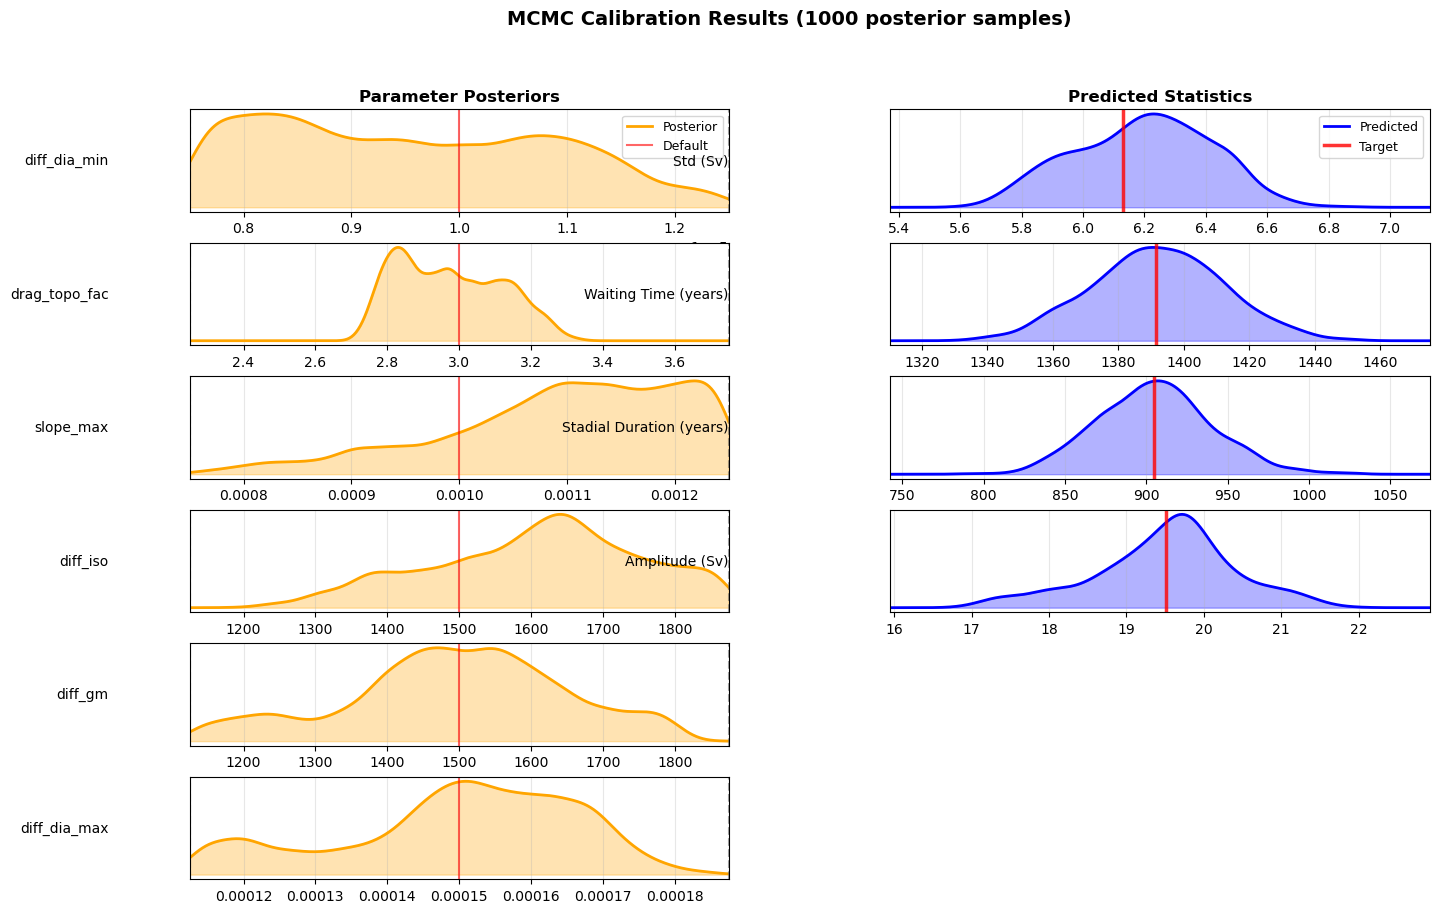

PDF overlay saved to: mcmc_pdf_overlay_pca.pdf


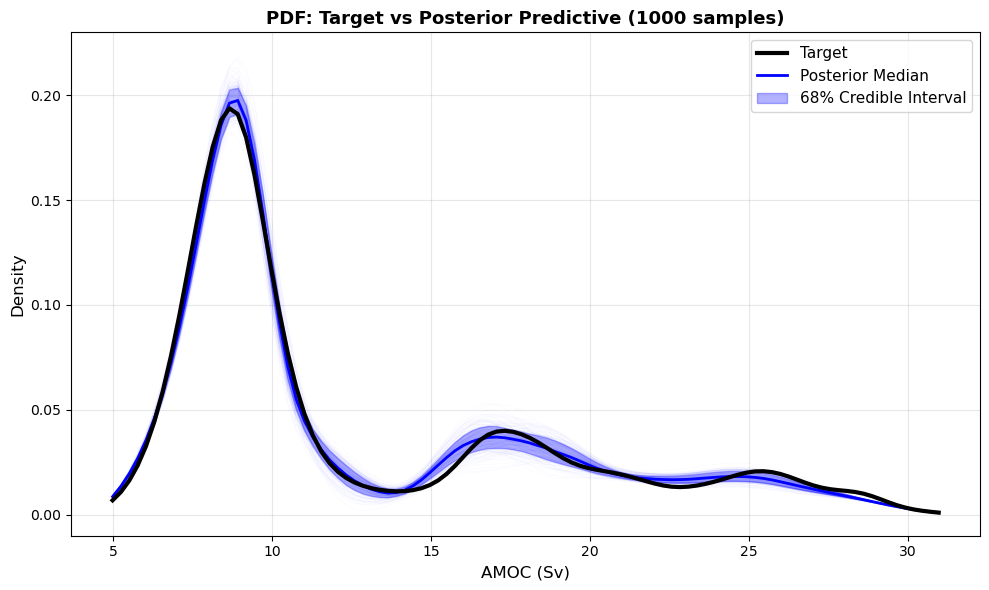


POSTERIOR PREDICTIVE SUMMARY

Statistic                 Target          Pred Mean       Pred Std        Coverage  
--------------------------------------------------------------------------------
Mean                      12.601          12.476          0.657           ✓         
Std                       6.131           6.196           0.221           ✓         
Stadial Duration          904.942         905.237         34.914          ✓         
Waiting Time              1391.529        1392.001        19.895          ✓         
Amplitude                 19.508          19.505          0.894           ✓         
N Stadials                52.000          52.132          1.074           ✓         

PDF RMSE                  -               0.0049          0.0009         

IMPROVEMENT OVER DEFAULT PARAMETERS

PDF RMSE:
  Default parameters: 0.0078
  Posterior mean:     0.0049
  Improvement:        36.6%

Summary Statistics Errors (MAE):
  Mean                      Default:    0.111  Pos

In [26]:
# -----------------------------
# Draw samples from posterior and get predictions
# -----------------------------
n_posterior_samples = 1000  # Number of samples to draw from posterior
random_idx = np.random.choice(len(posterior_samples), size=n_posterior_samples, replace=False)
sampled_params = posterior_samples[random_idx]

# Get predictions for all sampled parameters
pred_pdfs_list = []
pred_stats_list = []

print(f"Drawing {n_posterior_samples} samples from posterior and making predictions...")
for theta in sampled_params:
    theta_reshaped = theta.reshape(1, -1)
    pca_pred, pred_stats = gp_emul.predict(theta_reshaped, return_std=False)
    pdf_pred = gp_emul.reconstruct_pdf(pca_pred)
    pred_pdfs_list.append(pdf_pred.flatten())
    pred_stats_list.append(pred_stats.flatten())

pred_pdfs_array = np.array(pred_pdfs_list)  # shape: (n_samples, n_grid_points)
pred_stats_array = np.array(pred_stats_list)  # shape: (n_samples, 6)

# -----------------------------
# Combined plot: Parameters + Predictions
# -----------------------------
from scipy.stats import gaussian_kde

# Define target values
target_values = [
    default_stats['mean'],
    default_stats['std'],
    default_stats['avg_stadial_duration'],
    default_stats['avg_waiting_time'],
    default_stats['avg_amplitude'],
    default_stats['n_stadials']
]

# Extract bounds for plotting
bounds = [(lower_bounds[i], upper_bounds[i]) for i in range(ndim)]
n_params = len(param_names)

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(n_params, 2, hspace=0.3, wspace=0.3)

# Left column: Parameter posteriors
for j in range(n_params):
    ax = fig.add_subplot(gs[j, 0])
    lb, ub = bounds[j]
    
    # KDE for parameter posterior
    data_param = posterior_samples[:, j]
    kde_param = gaussian_kde(data_param)
    x_vals = np.linspace(lb, ub, 500)
    y_vals_param = kde_param(x_vals)
    
    ax.plot(x_vals, y_vals_param, color='orange', linewidth=2, label='Posterior')
    ax.fill_between(x_vals, y_vals_param, alpha=0.3, color='orange')
    
    # Prior bounds
    ax.axvline(lb, color='#696969', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.axvline(ub, color='#696969', linestyle='--', alpha=0.6, linewidth=1.5)
    
    # Default parameter
    default_val = theta_default[j]
    ax.axvline(default_val, color='red', linestyle='-', alpha=0.6, 
              linewidth=1.5, label='Default')
    
    ax.set_xlim(lb, ub)
    ax.set_ylabel(param_names[j], rotation=0, ha='right', va='center', fontsize=10)
    ax.yaxis.set_label_coords(-0.15, 0.5)
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.3)
    if j == 0:
        ax.legend(loc='upper right', fontsize=9)
        ax.set_title('Parameter Posteriors', fontweight='bold', fontsize=12)

# Right column: Predicted statistics (select key ones)
# pred_stats format: [mean, std, avg_stadial_duration, avg_waiting_time, avg_amplitude, n_stadials]
key_stats = [1, 3, 2, 4]  # std, waiting_time, stadial_duration, amplitude
key_names = ['Std (Sv)', 'Waiting Time (years)', 
             'Stadial Duration (years)', 'Amplitude (Sv)']

for idx, (stat_idx, stat_name) in enumerate(zip(key_stats, key_names)):
    ax = fig.add_subplot(gs[idx, 1])
    
    data_posterior = pred_stats_array[:, stat_idx]
    target_val = target_values[stat_idx]
    
    data_min = np.min(data_posterior)
    data_max = np.max(data_posterior)
    data_range = data_max - data_min
    lb_plot = data_min - 0.2 * data_range
    ub_plot = data_max + 0.2 * data_range
    
    if np.std(data_posterior) > 0:
        kde_posterior = gaussian_kde(data_posterior)
        x_vals = np.linspace(lb_plot, ub_plot, 500)
        y_vals_posterior = kde_posterior(x_vals)
        ax.plot(x_vals, y_vals_posterior, color='blue', linewidth=2, 
               label='Predicted')
        ax.fill_between(x_vals, y_vals_posterior, alpha=0.3, color='blue')
    
    ax.axvline(target_val, color='red', linestyle='-', linewidth=2.5, 
              label='Target', alpha=0.8)
    
    ax.set_xlim(lb_plot, ub_plot)
    ax.set_ylabel(stat_name, rotation=0, ha='right', va='center', fontsize=10)
    ax.yaxis.set_label_coords(-0.3, 0.5)
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.3)
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)
        ax.set_title('Predicted Statistics', fontweight='bold', fontsize=12)

plt.suptitle(f'MCMC Calibration Results ({n_posterior_samples} posterior samples)', 
            fontsize=14, fontweight='bold')
plt.savefig('mcmc_calibration_combined_pca.pdf', dpi=300, bbox_inches='tight')
print("Combined figure saved to: mcmc_calibration_combined_pca.pdf")
plt.show()

# -----------------------------
# Additional: PDF overlay plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Plot target PDF
ax.plot(x_grid, pdf_target, 'k-', linewidth=3, label='Target', zorder=10)

# Plot posterior predictive PDFs (sample)
n_plot_samples = min(200, len(pred_pdfs_array))
sample_indices = np.random.choice(len(pred_pdfs_array), n_plot_samples, replace=False)

for i in sample_indices:
    ax.plot(x_grid, pred_pdfs_array[i], 'b-', alpha=0.02, linewidth=0.5)

# Plot median and credible intervals
pdf_median = np.median(pred_pdfs_array, axis=0)
pdf_lower = np.percentile(pred_pdfs_array, 16, axis=0)
pdf_upper = np.percentile(pred_pdfs_array, 84, axis=0)

ax.plot(x_grid, pdf_median, 'b-', linewidth=2, label='Posterior Median', zorder=9)
ax.fill_between(x_grid, pdf_lower, pdf_upper, alpha=0.3, color='blue', 
                label='68% Credible Interval', zorder=8)

ax.set_xlabel('AMOC (Sv)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'PDF: Target vs Posterior Predictive ({n_posterior_samples} samples)', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mcmc_pdf_overlay_pca.pdf', dpi=300, bbox_inches='tight')
print("PDF overlay saved to: mcmc_pdf_overlay_pca.pdf")
plt.show()

# -----------------------------
# Summary statistics table
# -----------------------------
print("\n" + "="*70)
print("POSTERIOR PREDICTIVE SUMMARY")
print("="*70)

stat_names_full = ['Mean', 'Std', 'Stadial Duration', 'Waiting Time', 'Amplitude', 'N Stadials']

print(f"\n{'Statistic':<25} {'Target':<15} {'Pred Mean':<15} {'Pred Std':<15} {'Coverage':<10}")
print("-"*80)

for i, name in enumerate(stat_names_full):
    target = target_values[i]
    pred_mean = np.mean(pred_stats_array[:, i])
    pred_std = np.std(pred_stats_array[:, i])
    
    # Check if target is within 1 std of prediction
    within_1std = abs(target - pred_mean) <= pred_std
    coverage = "✓" if within_1std else "✗"
    
    print(f"{name:<25} {target:<15.3f} {pred_mean:<15.3f} {pred_std:<15.3f} {coverage:<10}")

# PDF summary
pdf_rmse_per_sample = np.sqrt(np.mean((pdf_target - pred_pdfs_array)**2, axis=1))
pdf_rmse_mean = np.mean(pdf_rmse_per_sample)
pdf_rmse_std = np.std(pdf_rmse_per_sample)

print(f"\n{'PDF RMSE':<25} {'-':<15} {pdf_rmse_mean:<15.4f} {pdf_rmse_std:<15.4f}")

print("="*70)

# -----------------------------
# Quantify improvement over default
# -----------------------------
print("\n" + "="*70)
print("IMPROVEMENT OVER DEFAULT PARAMETERS")
print("="*70)

# Predict with default parameters
pca_default, stats_default_pred = gp_emul.predict(theta_default.reshape(1, -1), return_std=False)
pdf_default_pred = gp_emul.reconstruct_pdf(pca_default).flatten()

# Default errors
pdf_rmse_default = np.sqrt(np.mean((pdf_target - pdf_default_pred)**2))

print(f"\nPDF RMSE:")
print(f"  Default parameters: {pdf_rmse_default:.4f}")
print(f"  Posterior mean:     {pdf_rmse_mean:.4f}")
print(f"  Improvement:        {(1 - pdf_rmse_mean/pdf_rmse_default)*100:.1f}%")

print(f"\nSummary Statistics Errors (MAE):")
for i, name in enumerate(stat_names_full):
    target = target_values[i]
    default_error = abs(target - stats_default_pred[0, i])
    posterior_error = np.mean(np.abs(target - pred_stats_array[:, i]))
    improvement = (1 - posterior_error/default_error)*100 if default_error > 0 else 0
    
    print(f"  {name:<25} Default: {default_error:>8.3f}  Posterior: {posterior_error:>8.3f}  " +
          f"Improvement: {improvement:>6.1f}%")

print("="*70)